In [1]:
!pip install numpy pandas matplotlib scikit-learn scipy seaborn


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from typing import Callable, List, Tuple, Optional
from abc import ABC, abstractmethod

## Frank-Wolfe Algorithm
The Frank-Wolfe algorithm, also known as the Conditional Gradient Method, is an iterative optimization technique designed for constrained convex optimization problems. It works by iteratively solving linear approximations of the objective function over the feasible set.

### Step Size Strategies

The Frank-Wolfe algorithm supports several step size determination strategies:

1. **Armijo Line Search**: A backtracking line search that ensures sufficient decrease in the objective. It starts with a large step size and reduces it until a sufficient decrease condition is met. (Section 4 FW_survey.pdf)

2. **Diminishing Step Size**: Uses a predefined schedule γₖ = 2/(k+2), which guarantees convergence while avoiding costly line searches. (Algorithm 1 FW.pdf, Section 4 FW_survey.pdf)

3. **Exact Line Search**: Finds the optimal step size by solving
    γₖ = argmin_{γ∈[0,1]} f((1-γ)xₖ + γsₖ)
    This provides the best progress per iteration but requires solving a one-dimensional optimization problem. (Algorithm 3 FW.pdf and Section 4 FW_survey.pdf)

4. **Exact Line Search for Away and Pairwise Variants**: For away-step and pairwise variants, the exact line search is modified to:
   γₖ = argmin_{γ∈[0,γₘₐₓ]} f(x(ᵏ) + γdₖ)

   where γₘₐₓ may be restricted to less than 1 for away steps to ensure feasibility. (Algorithm 1 FW_variants.pdf)

In [2]:
class FrankWolfeBase(ABC):
    """Abstract base class for Frank-Wolfe algorithm variants"""

    def __init__(self, max_iter: int = 1000, tol: float = 1e-6, line_search_strategy: str = 'exact') -> None:
        self.max_iter = max_iter
        self.tol = tol
        self.line_search_strategy = line_search_strategy

        self.x_pred: Optional[np.ndarray] = None
        self.iter: int = 0
        self.loss_history: List[float] = []
        self.cpu_time_history: List[float] = []
        self.gap_history: List[float] = []

    @abstractmethod
    def fit(self, objective_function: Callable[[np.ndarray], float],
            compute_gradient: Callable[[np.ndarray], np.ndarray],
            lmo: Callable[[np.ndarray], np.ndarray],
            x0: np.ndarray) -> np.ndarray:
        """Solve the optimization problem starting from x0"""
        pass

    def _line_search(self, objective_function: Callable[[np.ndarray], float],
                     x: np.ndarray, k: int, direction: np.ndarray,
                     grad: np.ndarray, max_step_size: float = 1.0) -> float:
        """Line search to find the optimal step size"""
        step_size = max_step_size

        if self.line_search_strategy == 'armijo':
            step_size = max_step_size

            # TODO: try different hyperparams on exact problem
            gamma = 0.1
            delta = 0.5

            f_x = objective_function(x)

            ref = gamma * (grad @ direction)

            while True:
                x_new = x + step_size * direction
                f_x_new = objective_function(x_new)

                if f_x_new <= f_x + step_size * ref:
                    break
                else:
                    step_size *= delta

                # Fixed step size if step size becomes too small
                if step_size <= 1e-10:
                    step_size = max_step_size
                    break

        elif self.line_search_strategy == 'diminishing':
            step_size = min(2 / (k + 2), max_step_size)

        # TODO: exact and exact_bounded strats are problem specific
        # suggest to omit them for simplicity
        elif self.line_search_strategy == 'exact':
            raise NotImplementedError('Exact line search needs to be implemented')

        elif self.line_search_strategy == 'exact_bounded':
            raise NotImplementedError('Exact line search for away and pairwise FW needs to be implemented')

        else:
            raise ValueError("Invalid line search strategy")

        return step_size

### Frank Wolfe

*Algorithm 1 FW.pdf*

1. Start with an initial feasible point x₀
2. At each iteration k:
    - Compute the gradient ∇f(xₖ)
    - Find the point s in the feasible set that minimizes ⟨s, ∇f(xₖ)⟩
    - Determine the step size γₖ
    - Update: xₖ₊₁ = (1-γₖ)xₖ + γₖs

In [3]:
class FrankWolfe(FrankWolfeBase):
    """Standard Frank-Wolfe algorithm implementation"""

    def __init__(self, max_iter: int = 1000, tol: float = 1e-6, line_search_strategy: str = 'exact') -> None:
        super().__init__(max_iter, tol, line_search_strategy)

    def fit(self, objective_function: Callable[[np.ndarray], float],
            compute_gradient: Callable[[np.ndarray], np.ndarray],
            lmo: Callable[[np.ndarray], np.ndarray],
            x0: np.ndarray) -> np.ndarray:
        """Solve the optimization problem using standard Frank-Wolfe"""
        start_time = time.time()

        x = x0.copy()

        # Reset history
        self.loss_history = [objective_function(x)]
        self.cpu_time_history = [0.0]
        self.gap_history = []

        for k in range(self.max_iter):
            grad = compute_gradient(x)

            # Compute FW direction
            s = lmo(grad)

            gap = -grad @ (s - x)

            # Check convergence
            if gap < self.tol:
                break

            # Direction and step size
            d = s - x
            step_size = self._line_search(objective_function, x, k, d, grad)

            # Update solution
            x = x + step_size * d

            # Update history
            self.iter = k + 1
            self.gap_history.append(gap)
            self.loss_history.append(objective_function(x))
            self.cpu_time_history.append(time.time() - start_time)

        # Save the final solution
        self.x_pred = x.copy()

        return x

### Away Step Frank-Wolfe

*Algorithm 1 FW_variants.pdf*

1. Start with an initial feasible point x₀ and initialize active set S₀ = {x₀}
2. At each iteration k:
    - Compute the gradient ∇f(xₖ)
    - Find the Frank-Wolfe direction: Find sₖ in the feasible set that minimizes ⟨sₖ, ∇f(xₖ)⟩, set dᶠʷ = sₖ - xₖ
    - Find the Away direction: Find vₖ in the active set Sₖ that maximizes ⟨vₖ, ∇f(xₖ)⟩, set dᵃʷᵃʸ = xₖ - vₖ
    - Compute the Frank-Wolfe gap gᶠʷ = ⟨-∇f(xₖ), dᶠʷ⟩
    - If gᶠʷ ≤ ε, terminate (convergence)
    - Choose the direction with greater potential decrease:
      - If ⟨-∇f(xₖ), dᶠʷ⟩ ≥ ⟨-∇f(xₖ), dᵃʷᵃʸ⟩:
         - Use dₖ = dᶠʷ (Frank-Wolfe direction)
         - Set γₘₐₓ = 1
      - Else:
         - Use dₖ = dᵃʷᵃʸ (Away direction)
         - Set γₘₐₓ = αᵥₖ/(1-αᵥₖ) (maximum feasible step size)
    - Determine the step size γₖ through line search in [0, γₘₐₓ]
    - Update: xₖ₊₁ = xₖ + γₖdₖ
    - Update the active set Sₖ₊₁

In [4]:
class AwayStepFrankWolfe(FrankWolfeBase):
    """Away Step Frank-Wolfe algorithm implementation"""

    def __init__(self, max_iter: int = 1000, tol: float = 1e-6, line_search_strategy: str = 'exact_bounded') -> None:
        super().__init__(max_iter, tol, line_search_strategy)

        self.active_set: List[Tuple[np.ndarray, float]] = None

    def _update_active_set(self, s: np.ndarray, a_idx: int, step_size: float, 
                          max_step_size: float, is_away: bool) -> List[Tuple[np.ndarray, float]]:
        """Update the active set

        For Frank-Wolfe steps:
        - If step_size = 1.0: Active set becomes just {s}
        - Otherwise: Add s to active set (if not already present)
        - Update weights:
          - For s: α_s = (1-step_size)*α_s + step_size
          - For other vertices v: α_v = (1-step_size)*α_v

        For Away steps:
        - If step_size = max_step_size: "Drop step" - remove away vertex completely
        - Otherwise: Keep away vertex with reduced weight
        - Update weights:
            - For away vertex: α_away = (1+step_size)*α_away - step_size
            - For other vertices v: α_v = (1+step_size)*α_v
        """
        new_active_set = []
        is_s_in_active_set = False

        # Away step case
        if is_away:
            is_drop_step = np.isclose(step_size, max_step_size)

            if is_drop_step:
                # Remove away vertex
                for v_idx, (vertex, weight) in enumerate(self.active_set):
                    if v_idx != a_idx:
                        # Rescale weights of remaining vertices
                        new_weight = weight / (1 - self.active_set[a_idx][1])
                        if new_weight > 1e-10:  # Numerical stability check
                            new_active_set.append((vertex, new_weight))
            else:
                # Update weights
                for v_idx, (vertex, weight) in enumerate(self.active_set):
                    if v_idx == a_idx:
                        # For away vertex: α_away = (1+step_size)*α_away - step_size
                        new_weight = (1 + step_size) * weight - step_size
                        if new_weight > 1e-10:  # Numerical stability check
                            new_active_set.append((vertex, new_weight))
                    else:
                        # For other vertices: α_v = (1+step_size)*α_v
                        new_active_set.append((vertex, (1 + step_size) * weight))
        # FW step case
        else:
            if np.isclose(step_size, 1.0):
                # Active set becomes just {s}
                new_active_set = [(s, 1.0)]
            else:
                for vertex, weight in self.active_set:
                    # For all vertices: α_v = (1-step_size)*α_v
                    new_weight = (1 - step_size) * weight

                    if np.array_equal(vertex, s):
                        # For s: α_s = (1-step_size)*α_s + step_size
                        new_weight += step_size
                        is_s_in_active_set = True

                    if new_weight > 1e-10:  # Numerical stability check
                        new_active_set.append((vertex, new_weight))

                # Add s to active set if not already present
                if not is_s_in_active_set:
                    new_active_set.append((s, step_size))

        return new_active_set

    def _compute_away_direction(self, grad: np.ndarray) -> Tuple[np.ndarray, int]:
        """Find the vertex in the active set with maximum inner product with gradient

        Need to maximize: max ⟨-∇f(x), x - v_t⟩

        ⟨-∇f(x), x - v_t⟩ = ⟨-∇f(x), x⟩ - ⟨-∇f(x), v_t⟩ = -⟨∇f(x), x⟩ + ⟨∇f(x), v_t⟩

        -⟨∇f(x), x⟩ is constant with respect to v_t, rewrite as: max ⟨∇f(x), v_t⟩
        """
        max_inner_product = -float('inf')
        away_vertex = None
        away_idx = None

        for i, (atom, weight) in enumerate(self.active_set):
            inner_product = grad @ atom
            if inner_product > max_inner_product:
                max_inner_product = inner_product
                away_vertex = atom
                away_idx = i

        return away_vertex, away_idx

    def fit(self, objective_function: Callable[[np.ndarray], float], 
            compute_gradient: Callable[[np.ndarray], np.ndarray], 
            lmo: Callable[[np.ndarray], np.ndarray], 
            x0: np.ndarray) -> np.ndarray:
        """Solve the optimization problem using Away Step Frank-Wolfe"""
        start_time = time.time()

        x = x0.copy()

        # Initialize active set: S(0) := {x(0)} with α(0)_x(0) = 1
        self.active_set = [(x0, 1.0)]

        # Reset history
        self.loss_history = [objective_function(x)]
        self.cpu_time_history = [0.0]
        self.gap_history = []

        for k in range(self.max_iter):
            grad = compute_gradient(x)

            # Compute FW direction
            s = lmo(grad)
            d_fw = s - x
            gap_fw = -(grad @ d_fw)

            # Check convergence
            if gap_fw < self.tol:
                break

            # Compute away direction
            a, a_idx = self._compute_away_direction(grad)
            d_away = x - a
            gap_away = -(grad @ d_away)

            # Choose direction
            is_away = gap_away > gap_fw
            if is_away:
                d = d_away
                away_weight = self.active_set[a_idx][1]
                max_step_size = away_weight / (1.0 - away_weight)
            else:
                d = d_fw
                max_step_size = 1.0

            # Step size
            step_size = self._line_search(objective_function, x, k, d, grad, max_step_size)

            # Update solution
            x = x + step_size * d

            # Update active set
            self.active_set = self._update_active_set(s, a_idx, step_size, max_step_size, is_away)

            # Update history
            self.iter = k + 1
            self.gap_history.append(gap_away if is_away else gap_fw)
            self.loss_history.append(objective_function(x))
            self.cpu_time_history.append(time.time() - start_time)

        # Save the final solution
        self.x_pred = x.copy()

        return x

### Pairwise Frank-Wolfe

*Algorithm 2 FW_variants.pdf*

1. Start with an initial feasible point x₀ and initialize active set S₀ = {x₀}
2. At each iteration k:
    - Compute the gradient ∇f(xₖ)
    - Find the Frank-Wolfe direction: Find sₖ in the feasible set that minimizes ⟨sₖ, ∇f(xₖ)⟩, set dᶠʷ = sₖ - xₖ
    - Find the Away direction: Find vₖ in the active set Sₖ that maximizes ⟨vₖ, ∇f(xₖ)⟩, set dᵃʷᵃʸ = xₖ - vₖ
    - Compute the Frank-Wolfe gap gᶠʷ = ⟨-∇f(xₖ), dᶠʷ⟩
    - If gᶠʷ ≤ ε, terminate (convergence)
    - Set the pairwise direction dₖ = sₖ - vₖ
    - Set γₘₐₓ = αᵥₖ (the weight of away vertex vₖ in the active set)
    - Determine the step size γₖ through line search in [0, γₘₐₓ]
    - Update: xₖ₊₁ = xₖ + γₖdₖ
    - Update the active set Sₖ₊₁

In [5]:
class PairwiseFrankWolfe(AwayStepFrankWolfe):
    """Pairwise Frank-Wolfe algorithm implementation"""

    def __init__(self, max_iter: int = 1000, tol: float = 1e-6, line_search_strategy: str = 'exact_bounded') -> None:
        super().__init__(max_iter, tol, line_search_strategy)

    def _update_active_set(self, s: np.ndarray, a_idx: int, step_size: float, max_step_size: float) -> List[Tuple[np.ndarray, float]]:
        """Update the active set

        For Pairwise steps:
        - Away vertex (v_a):
          - If step_size = γ_max: "Drop step" - remove away vertex completely
          - Otherwise: α_a = α_a - γ
        - FW vertex (s):
          - If already in active set: α_s = α_s + γ
          - If not in active set: Add to active set with weight α_s = γ
        - Other vertices:
          - Weights remain unchanged
        """
        new_active_set = []
        is_drop_step = np.isclose(step_size, max_step_size)
        is_s_in_active_set = False

        for v_idx, (vertex, weight) in enumerate(self.active_set):
            if v_idx == a_idx:
                # Away vertex case
                if is_drop_step:
                    # Drop step: remove away vertex completely when γ = γ_max
                    continue
                else:
                    # For away vertex v_a: α_v_a = α_v_a - γ
                    new_weight = weight - step_size
                    if new_weight > 1e-10:  # Numerical stability check
                        new_active_set.append((vertex, new_weight))
            elif np.array_equal(vertex, s):
                # For FW vertex s: α_s = α_s + γ
                new_weight = weight + step_size
                new_active_set.append((vertex, new_weight))
                is_s_in_active_set = True
            else:
                # For other vertices v: α_v remains unchanged
                new_active_set.append((vertex, weight))

        if not is_s_in_active_set:
            new_active_set.append((s, step_size))

        return new_active_set

    def fit(self, objective_function: Callable[[np.ndarray], float], 
            compute_gradient: Callable[[np.ndarray], np.ndarray], 
            lmo: Callable[[np.ndarray], np.ndarray], 
            x0: np.ndarray) -> np.ndarray:
        """Solve optimization problem using Pairwise Frank-Wolfe"""
        start_time = time.time()

        x = x0.copy()

        # Initialize active set: S(0) := {x(0)} with α(0)_x(0) = 1
        self.active_set = [(x0, 1.0)]

        # Reset history
        self.loss_history = [objective_function(x)]
        self.cpu_time_history = [0.0]
        self.gap_history = []

        for k in range(self.max_iter):
            grad = compute_gradient(x)

            # Compute FW direction
            s = lmo(grad)
            d_fw = s - x
            gap_fw = -(grad @ d_fw)

            # Check convergence using the standard FW gap
            if gap_fw < self.tol:
                break

            # Compute away direction
            a, a_idx = self._compute_away_direction(grad)

            # Compute direction
            d = s - a
            max_step_size = self.active_set[a_idx][1]

            gap = -(grad @ d)

            # Step size
            step_size = self._line_search(objective_function, x, k, d, grad, max_step_size)

            # Update solution
            x = x + step_size * d

            # Update active set
            self.active_set = self._update_active_set(s, a_idx, step_size, max_step_size)

            # Update history
            self.iter = k + 1
            self.gap_history.append(gap)
            self.loss_history.append(objective_function(x))
            self.cpu_time_history.append(time.time() - start_time)

        # Save the final solution
        self.x_pred = x.copy()

        return x

## Algorithm performance visualization

In [6]:
def plot_metrics(solver: FrankWolfeBase, figsize: Tuple[int, int] = (14, 4), title: Optional[str] = None) -> None:
    """Plot the loss, CPU time, and gap history of the solver"""
    fig, axs = plt.subplots(1, 3, figsize=figsize)

    # Plot loss history over iterations
    axs[0].plot(solver.loss_history)
    axs[0].set_xlabel('Iterations')
    axs[0].set_ylabel('Loss')
    axs[0].grid(True, alpha=0.3)

    # Plot gap history over iterations
    axs[1].plot(solver.gap_history)
    axs[1].set_xlabel('Iterations')
    axs[1].set_ylabel('Gap')
    axs[1].grid(True, alpha=0.3)

    # Plot CPU time history over iterations
    axs[2].plot(solver.cpu_time_history)
    axs[2].set_xlabel('Iterations')
    axs[2].set_ylabel('CPU Time (s)')
    axs[2].grid(True, alpha=0.3)

    if title:
        fig.suptitle(title, fontsize=16)

    plt.tight_layout()
    plt.show()


def compare_solvers(solvers: List[FrankWolfeBase], labels: List[str], figsize: Tuple[int, int] = (14, 4)) -> None:
    """Compare multiple solvers on the same problem"""
    fig, axs = plt.subplots(1, 3, figsize=figsize)
    colors = sns.color_palette("husl", len(solvers))

    line_styles = ['solid', 'dashed', 'dotted', 'dashdot']

    # Loss plot over iterations
    for i, (solver, label) in enumerate(zip(solvers, labels)):
        axs[0].plot(solver.loss_history, label=label, color=colors[i], linestyle=line_styles[i % len(line_styles)])

    axs[0].set_title('Loss vs Iterations', fontsize=14)
    axs[0].set_xlabel('Iterations')
    axs[0].set_ylabel('Loss')
    axs[0].grid(True, alpha=0.3)
    axs[0].legend()

    # Gap plot over iterations
    for i, (solver, label) in enumerate(zip(solvers, labels)):
        axs[1].plot(solver.gap_history, label=label, color=colors[i], linestyle=line_styles[i % len(line_styles)])
    
    axs[1].set_title('Gap vs Iterations', fontsize=14)
    axs[1].set_xlabel('Iterations')
    axs[1].set_ylabel('Gap')
    axs[1].grid(True, alpha=0.3)
    axs[1].legend()

    # CPU time plot over iterations
    for i, (solver, label) in enumerate(zip(solvers, labels)):
        axs[2].plot(solver.cpu_time_history, label=label, color=colors[i], linestyle=line_styles[i % len(line_styles)])

    axs[2].set_title('CPU Time vs Iterations', fontsize=14)
    axs[2].set_xlabel('Iterations')
    axs[2].set_ylabel('CPU Time (s)')
    axs[2].grid(True, alpha=0.3)
    axs[2].legend()

    plt.tight_layout()
    plt.show()

## Test on Convex Quadratic Function

In [16]:
def solve_quadratic_simplex(n: int, solver: FrankWolfeBase, random_seed: int = 123) -> FrankWolfeBase:
    """Solve a quadratic optimization problem over the unit simplex using the specified solver"""

    np.random.seed(random_seed)

    # Positive definite matrix Q
    A = np.random.randn(n, n)
    Q = A.T @ A + np.eye(n)

    # Linear term b
    b = np.random.randn(n)

    def objective_function(x: np.ndarray) -> float:
        """Objective function: f(x) = (1/2) x^T Q x + b^T x"""
        return 0.5 * x.T @ Q @ x + b.T @ x

    def compute_gradient(x: np.ndarray) -> np.ndarray:
        """Gradient: ∇f(x) = Q x + b"""
        return Q @ x + b

    def lmo(grad: np.ndarray) -> np.ndarray:
        """
        LMO for the unit simplex
        Returns the vertex e_i of the simplex that minimizes <e_i, grad>
        """
        # Find the index of the minimum component of the gradient
        s = np.zeros(n)
        i = np.argmin(grad)
        s[i] = 1.0
        return s

    # Initial point: center of the simplex
    x0 = np.ones(n) / n

    # Initial point: random point in the simplex
    # x0 = np.random.rand(n)
    # x0 = x0 / np.sum(x0)  # Normalization

    # Solving the optimization problem
    x_pred = solver.fit(objective_function, compute_gradient, lmo, x0)

    return solver

Solving quadratic simplex problem with FW (armijo)...


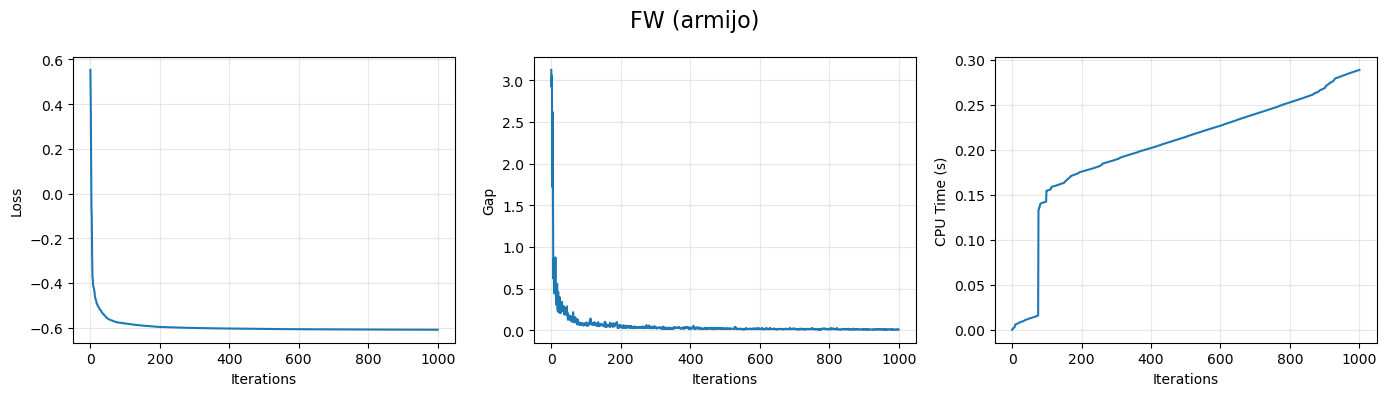

Solving quadratic simplex problem with FW (diminishing)...


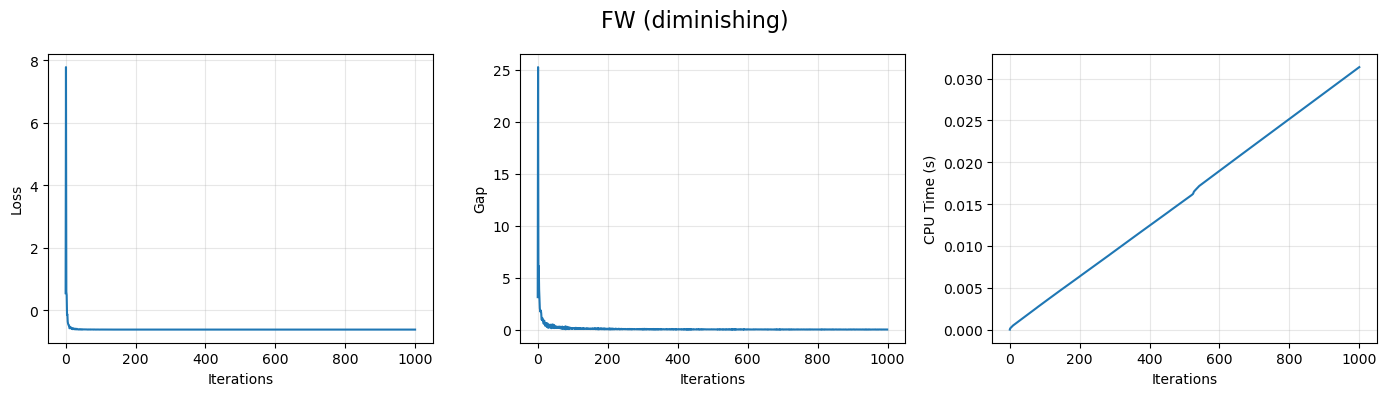

Solving quadratic simplex problem with Away Step FW (armijo)...


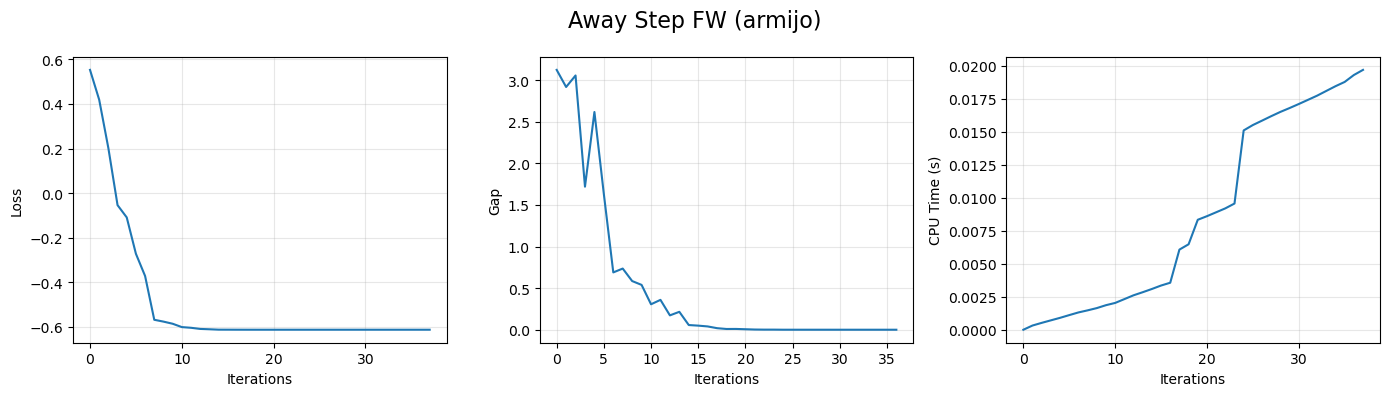

Solving quadratic simplex problem with Away Step FW (diminishing)...


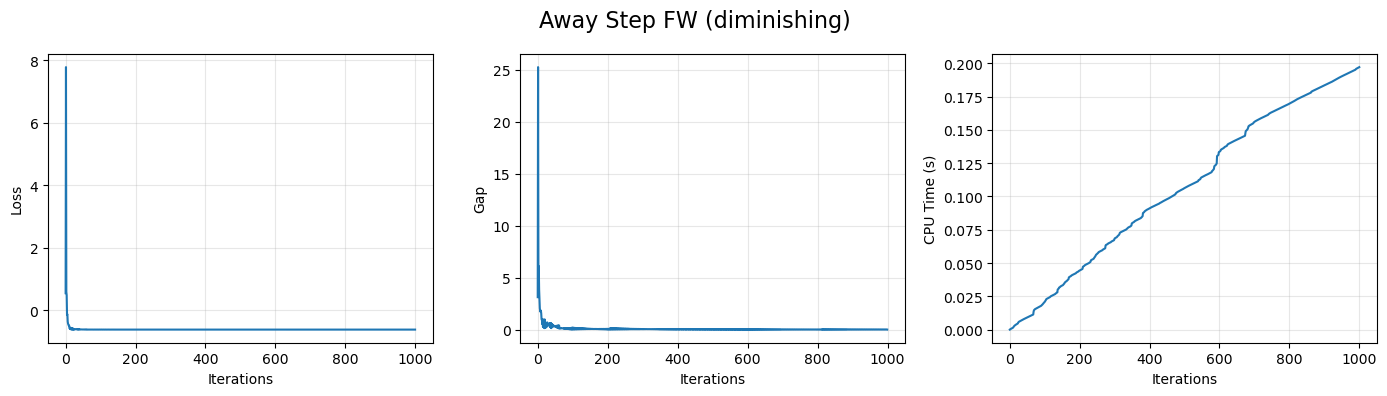

Solving quadratic simplex problem with Pairwise FW (armijo)...


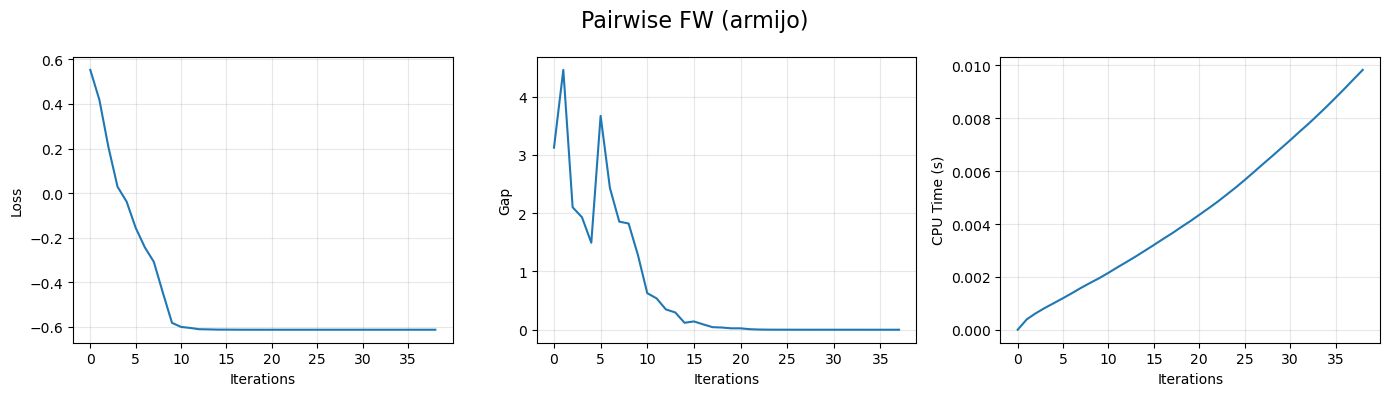

Solving quadratic simplex problem with Pairwise FW (diminishing)...


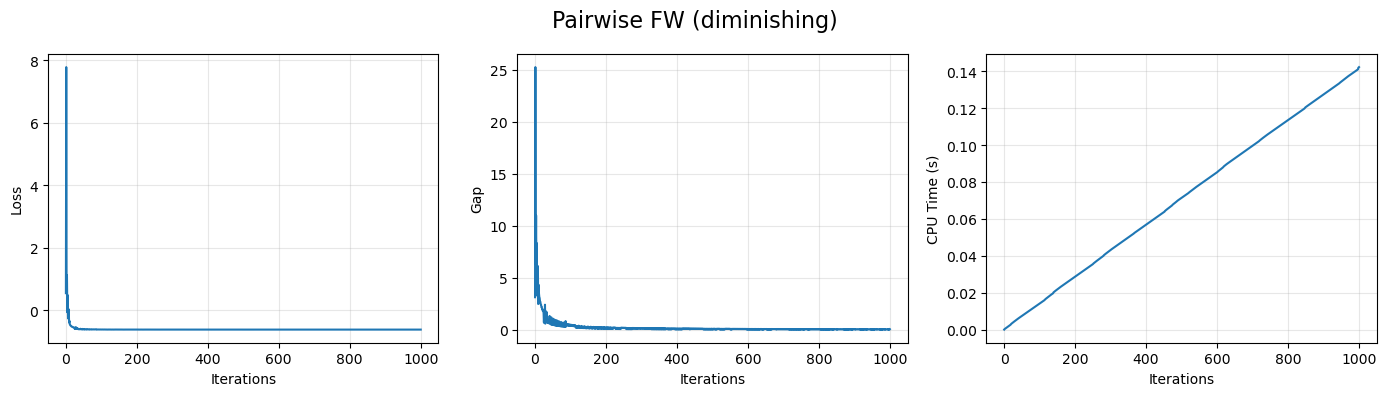

In [17]:
max_iter = 1000
tol = 1e-6
random_seed = 123
n = 10
line_search_strats = [
    'armijo', 
    'diminishing',
    # 'exact',          # Not implemented
    # 'exact_bounded'   # Not implemented
]
solver_configs = [
    (FrankWolfe, "FW", {}),
    (AwayStepFrankWolfe, "Away Step FW", {}),
    (PairwiseFrankWolfe, "Pairwise FW", {})
]

solvers = {}

for solver_class, solver_name, solver_dict in solver_configs:
    for line_search in line_search_strats:
        title = f'{solver_name} ({line_search})'
        print(f'Solving quadratic simplex problem with {title}...')

        solver = solver_class(max_iter, tol, line_search)
        fitted_solver = solve_quadratic_simplex(n, solver, random_seed)
        solver_dict[title] = fitted_solver

        plot_metrics(fitted_solver, title=title)

# Transfer to specific solver dict
fw_solvers = solver_configs[0][2]
fw_away_solvers = solver_configs[1][2]
fw_pw_solvers = solver_configs[2][2]

# Merge into a single dictionary
all_solvers = {
    **fw_solvers, 
    **fw_away_solvers, 
    **fw_pw_solvers
}

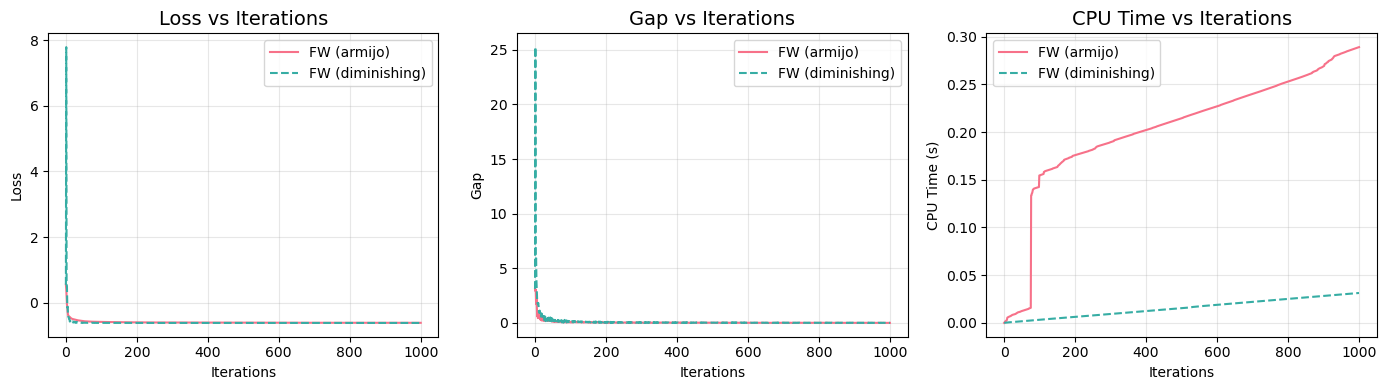

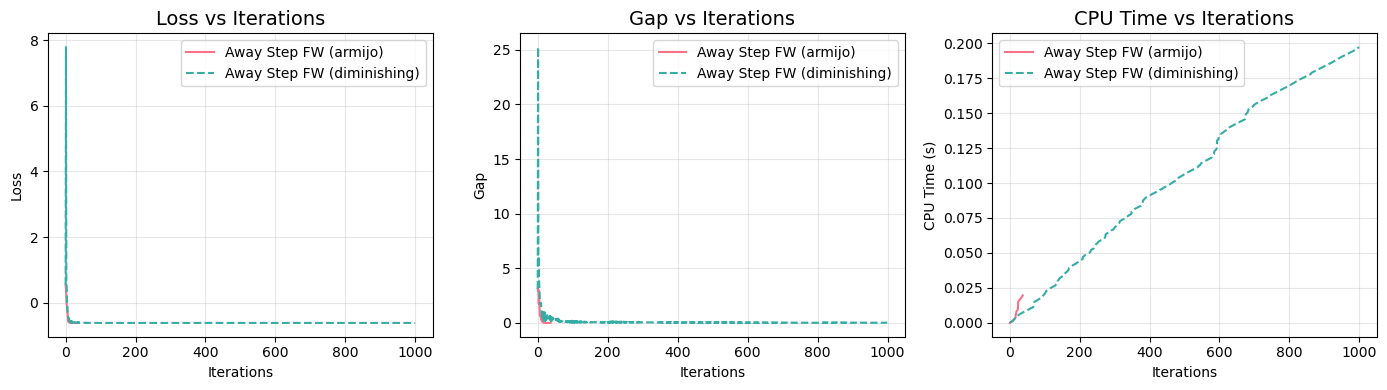

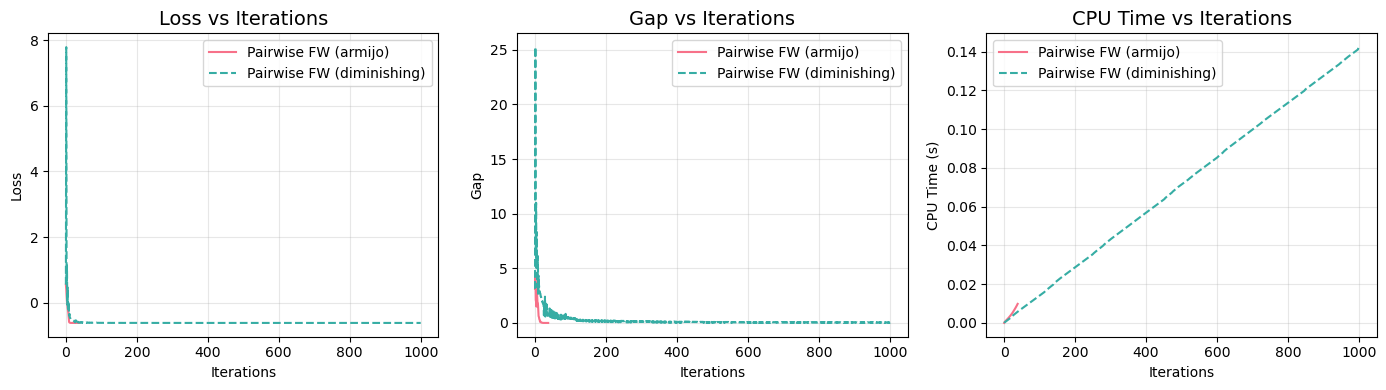

In [18]:
compare_solvers(list(fw_solvers.values()), list(fw_solvers.keys()))

compare_solvers(list(fw_away_solvers.values()), list(fw_away_solvers.keys()))

compare_solvers(list(fw_pw_solvers.values()), list(fw_pw_solvers.keys()))

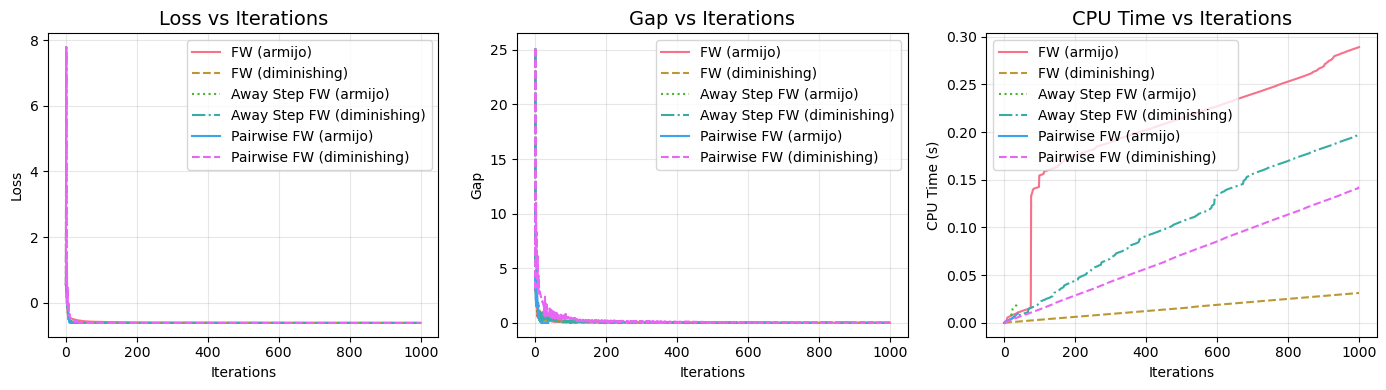

In [19]:
compare_solvers(list(all_solvers.values()), list(all_solvers.keys()))

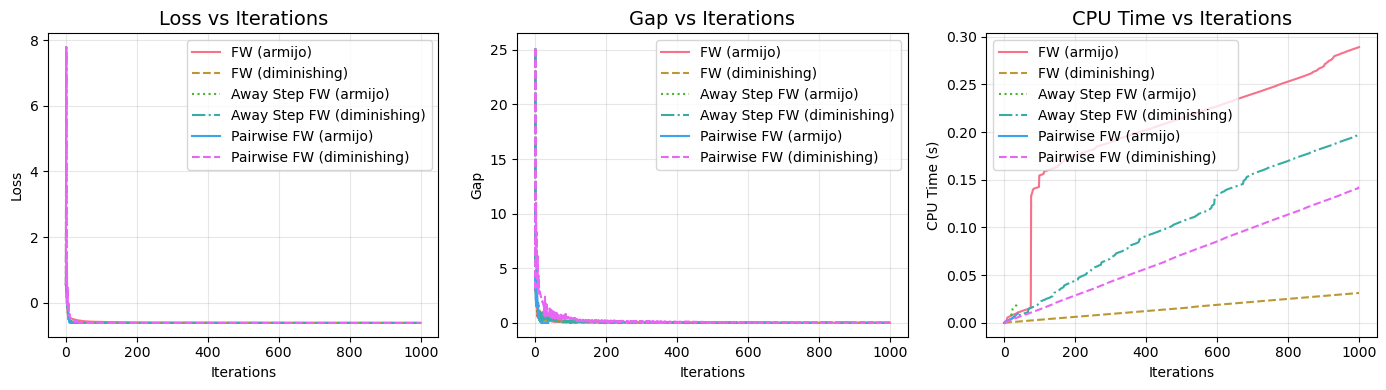

In [40]:
# Filter options (not applied if empty)
line_search_strats = [
    'armijo',
    'diminishing',
    # 'exact',
    # 'exact_bounded'
]
solver_classes = [
    FrankWolfe,
    AwayStepFrankWolfe,
    PairwiseFrankWolfe
]

filtered_solvers = {}

# Check if the solver matches the filter criteria
for solver_name, solver in all_solvers.items():
    if (
        not line_search_strats or solver.line_search_strategy in line_search_strats
    ) and (
        not solver_classes or solver.__class__ in solver_classes
    ):
        filtered_solvers[solver_name] = solver

compare_solvers(
    list(filtered_solvers.values()),
    list(filtered_solvers.keys())
)

## Test on Max-Clique Problem

The Motzkin-Strauss formulation transforms the discrete max-clique problem into a continuous quadratic programminf function:
 <br> <center> max $f(x) = x^T A x$
 <br> subject to $ x ∈ Δ $ </center>

Regularization is needed because of the spurious maximizer problem: 
<br> <center> max $ f_Φ(x) = x^T A x + Φ(x)$ </center>
We have 2 regularizers:
- $ Φ_B(x) = 1/2 ||x||_2^2$
      <br> l2 regularization, discourages sparsity
      <br> Gradient: $ ∇Φ_B(x)=x$
- $ Φ_2(x) = α_2 ∑_{i=1}^n (e^{−βx_i} -1) $
      <br> smooth non-convex regularization approximating l0 sparsity, promoted sparse solutions
      <br> Gradient: $ [∇Φ_2(x)_i] = -α_2βe^{−βx_i}$

In [41]:
def phi_l2(x):
    return 0.5 * np.dot(x, x)

def grad_phi_l2(x):
    return x

def phi_l0(x, alpha=0.1, beta=10):
    return alpha * np.sum(np.exp(-beta * x) - 1)

def grad_phi_l0(x, alpha=0.1, beta=10):
    return -alpha * beta * np.exp(-beta * x)
    
def solve_max_clique(graph_adj: np.ndarray, solver: FrankWolfeBase,
                    phi_func: Callable[[np.ndarray], float],
                    grad_phi_func: Callable[[np.ndarray], np.ndarray]) -> FrankWolfeBase:
    n = graph_adj.shape[0]
    A = graph_adj.astype(float)
    
    def regularized_objective_grad(A, phi, grad_phi):
        def objective(x):
            return -x.T @ A @ x - phi(x)

        def gradient(x):
            return -2 * A @ x - grad_phi(x)
        return objective, gradient

    def lmo(grad: np.ndarray) -> np.ndarray:
        s = np.zeros(n)
        s[np.argmin(grad)] = 1.0
        return s

    x0 = np.ones(n) / n
    objective, gradient = regularized_objective_grad(A, phi_func, grad_phi_func)

    solver.fit(objective, gradient, lmo, x0)
    return solver

In [51]:
import networkx as nx
from scipy.io import mmread
import urllib.request
import io

Solving Max Clique problem with FW (armijo + L2) on Max Clique...


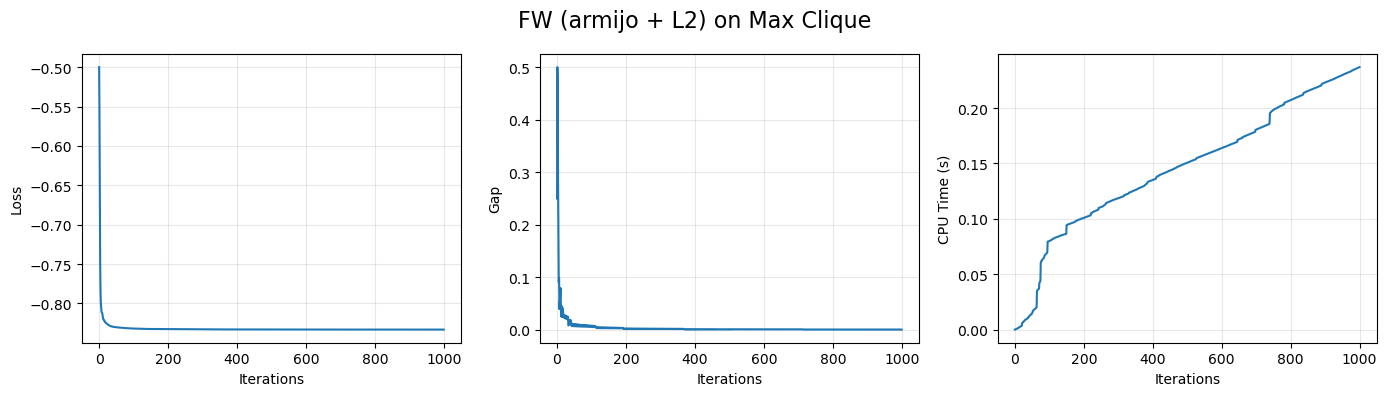

Estimated clique size for FW (armijo + L2) on Max Clique: 2.999
Solving Max Clique problem with FW (armijo + L0) on Max Clique...


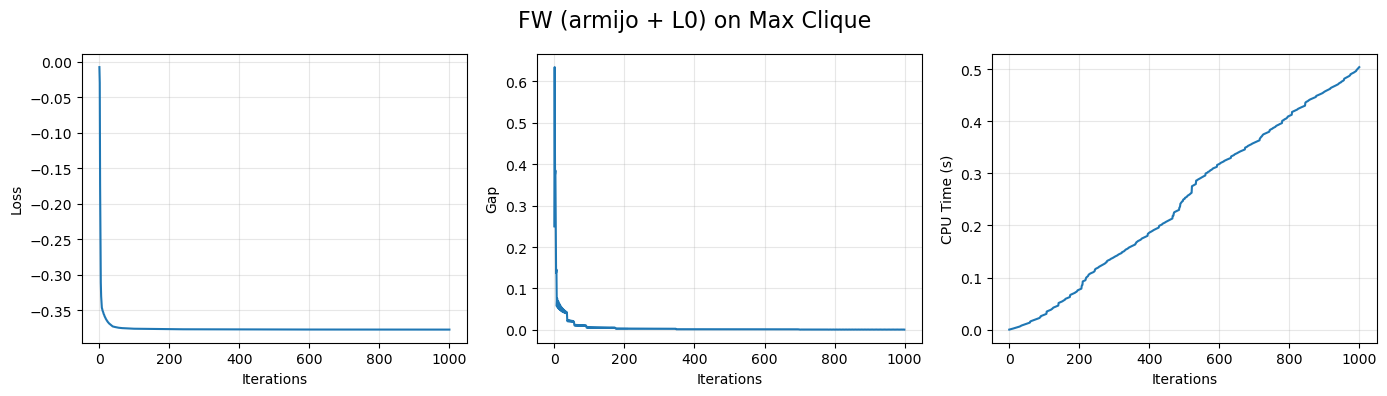

Estimated clique size for FW (armijo + L0) on Max Clique: 2.999
Solving Max Clique problem with FW (diminishing + L2) on Max Clique...


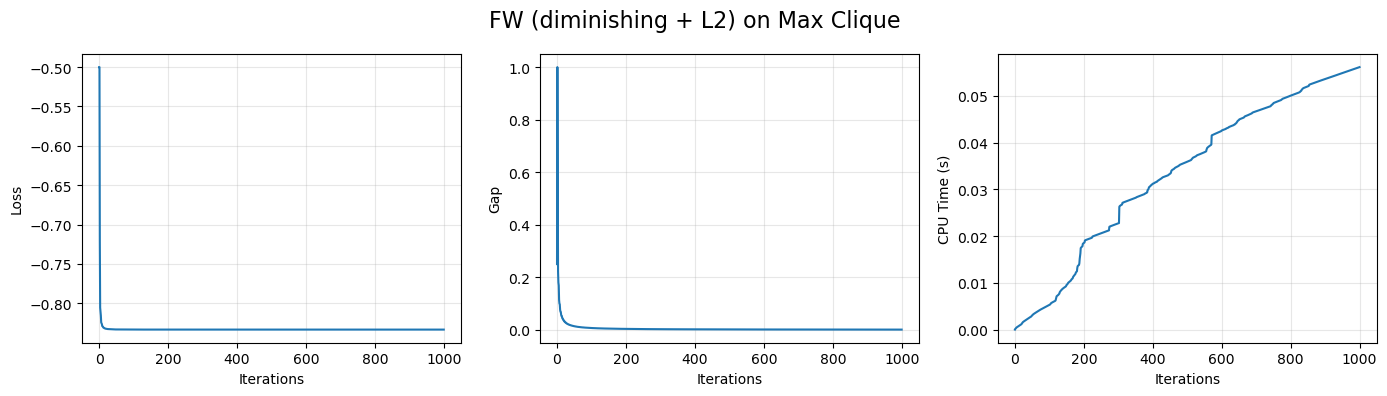

Estimated clique size for FW (diminishing + L2) on Max Clique: 3.000
Solving Max Clique problem with FW (diminishing + L0) on Max Clique...


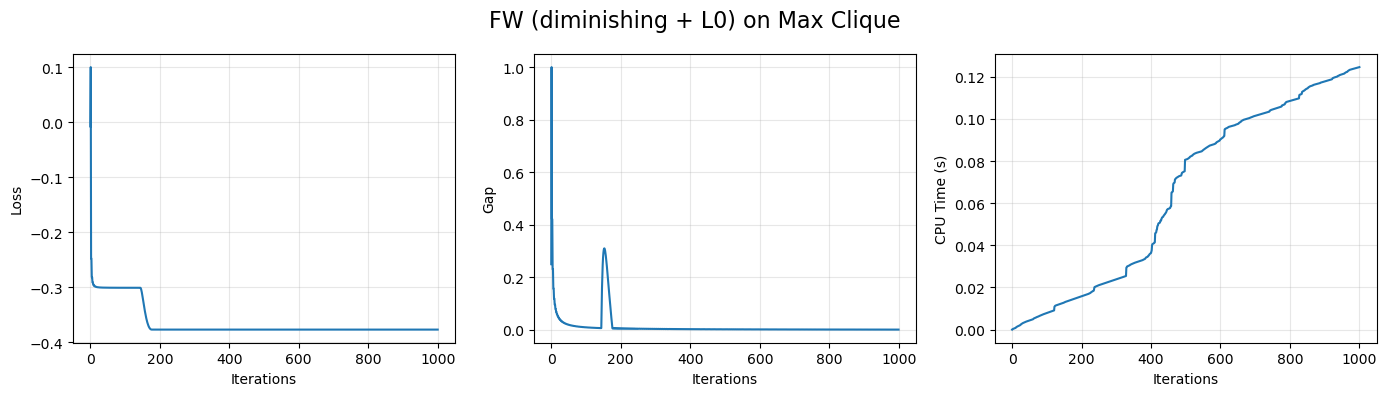

Estimated clique size for FW (diminishing + L0) on Max Clique: 3.000
Solving Max Clique problem with Away Step FW (armijo + L2) on Max Clique...


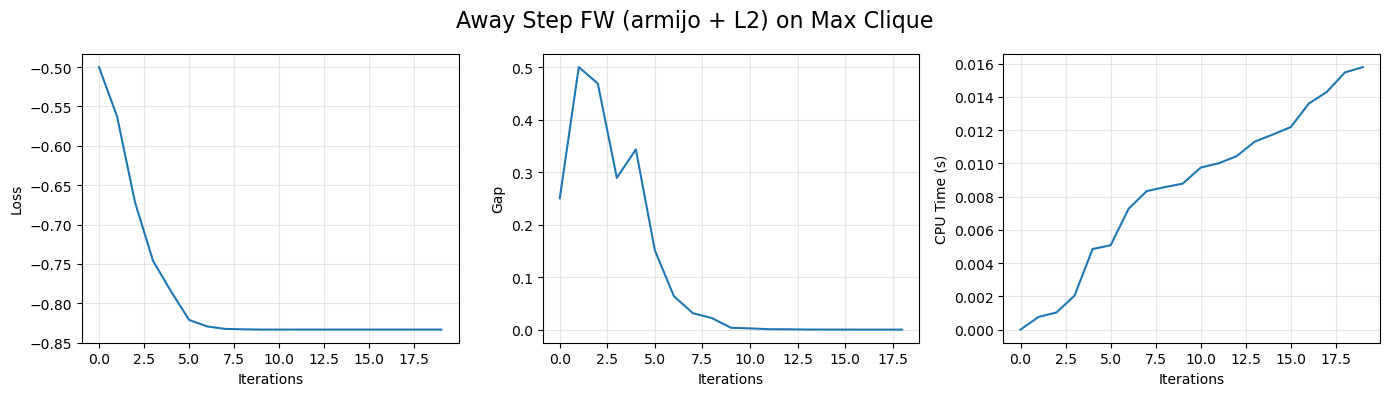

Estimated clique size for Away Step FW (armijo + L2) on Max Clique: 3.000
Solving Max Clique problem with Away Step FW (armijo + L0) on Max Clique...


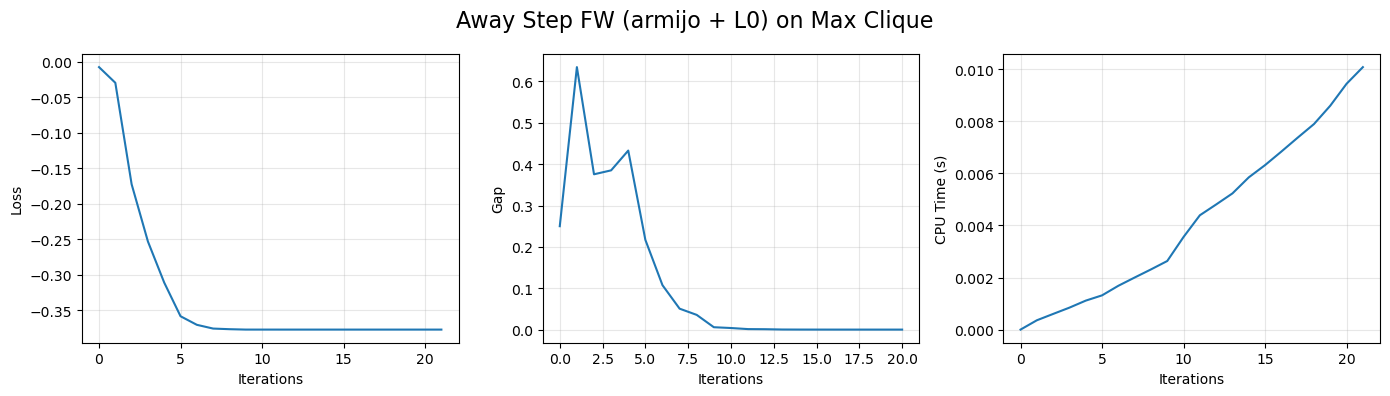

Estimated clique size for Away Step FW (armijo + L0) on Max Clique: 3.000
Solving Max Clique problem with Away Step FW (diminishing + L2) on Max Clique...


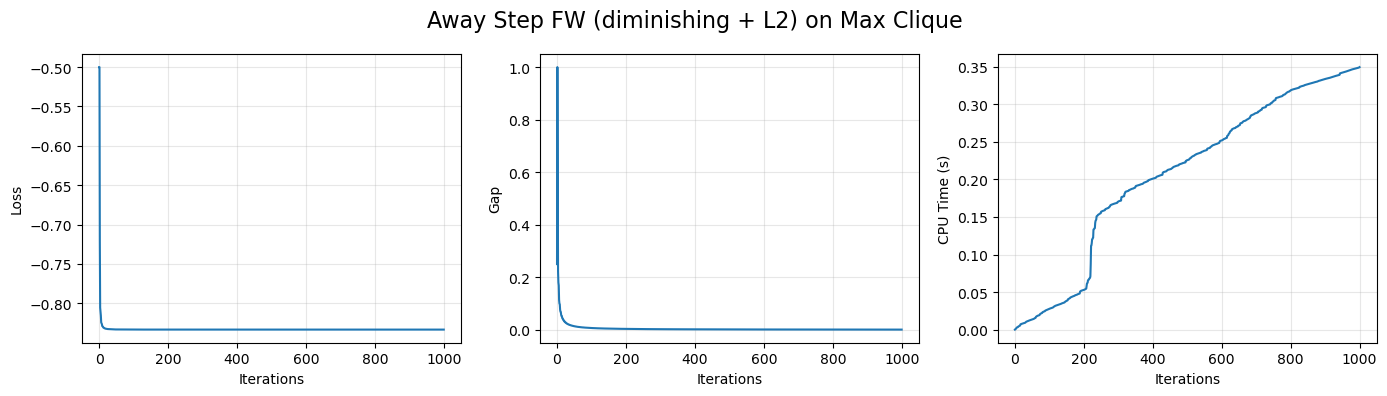

Estimated clique size for Away Step FW (diminishing + L2) on Max Clique: 3.000
Solving Max Clique problem with Away Step FW (diminishing + L0) on Max Clique...


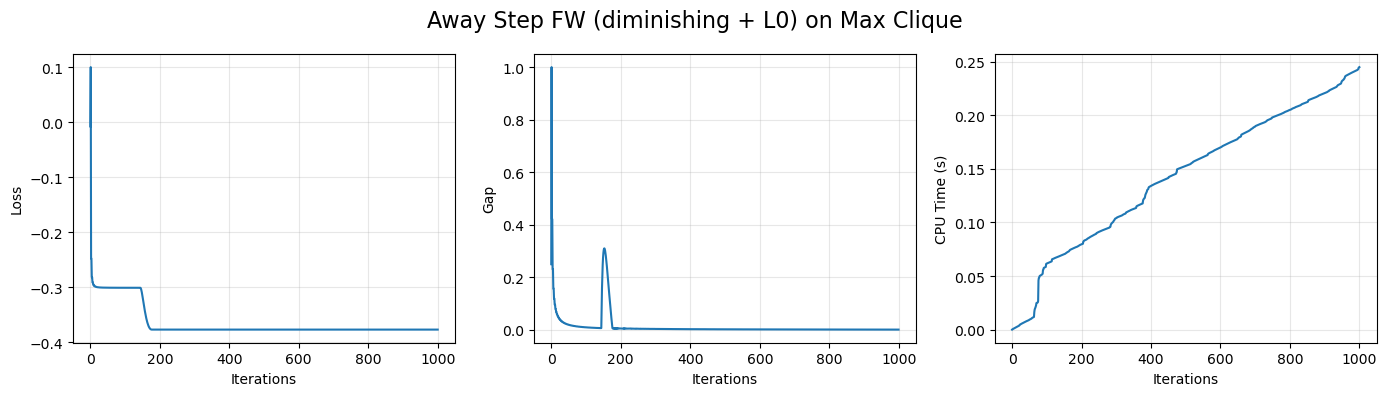

Estimated clique size for Away Step FW (diminishing + L0) on Max Clique: 3.000
Solving Max Clique problem with Pairwise FW (armijo + L2) on Max Clique...


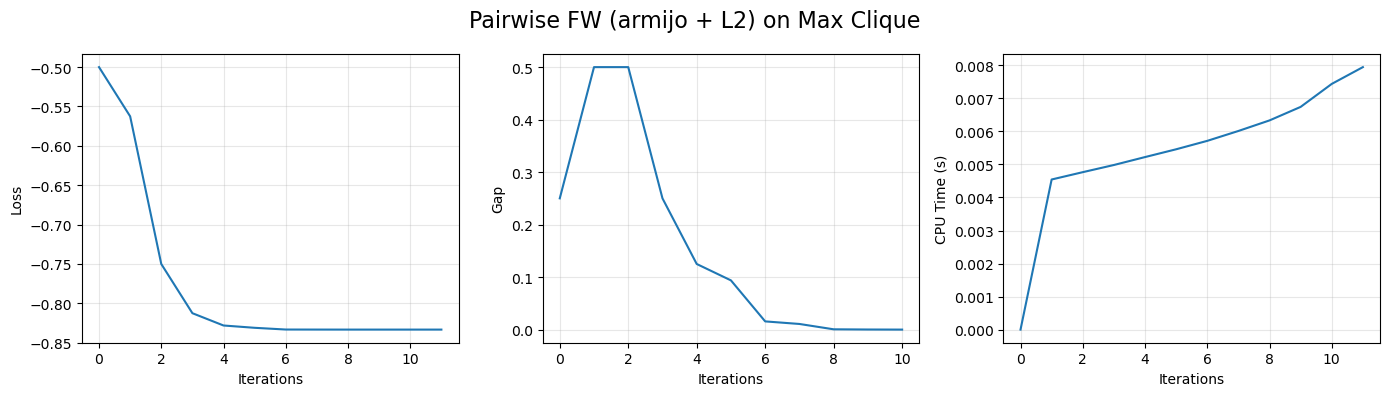

Estimated clique size for Pairwise FW (armijo + L2) on Max Clique: 3.000
Solving Max Clique problem with Pairwise FW (armijo + L0) on Max Clique...


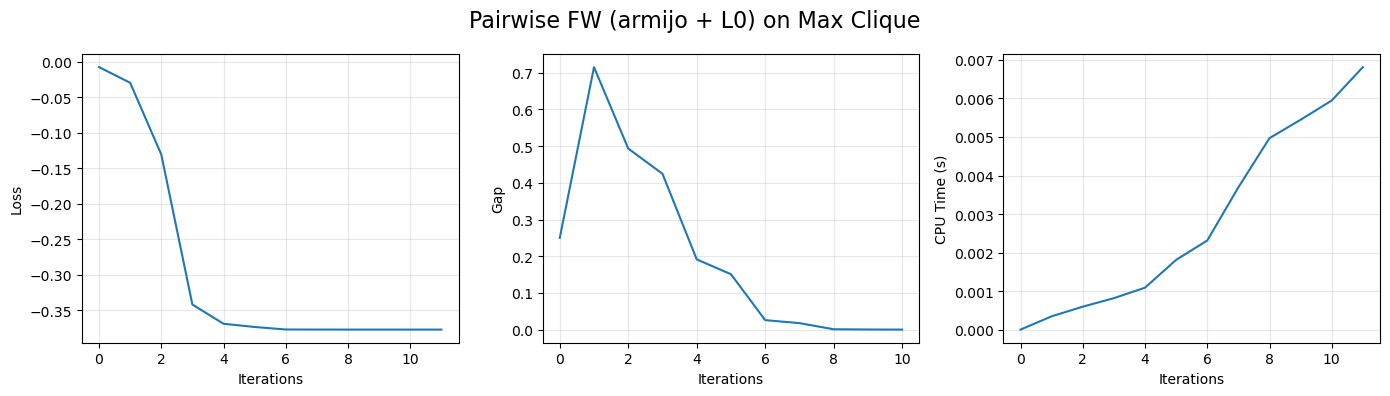

Estimated clique size for Pairwise FW (armijo + L0) on Max Clique: 3.000
Solving Max Clique problem with Pairwise FW (diminishing + L2) on Max Clique...


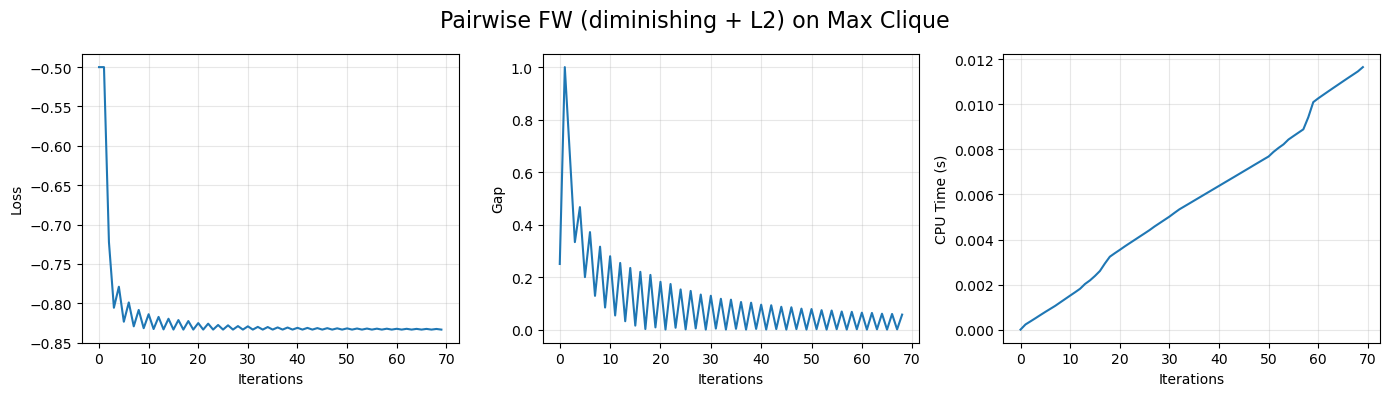

Estimated clique size for Pairwise FW (diminishing + L2) on Max Clique: 3.000
Solving Max Clique problem with Pairwise FW (diminishing + L0) on Max Clique...


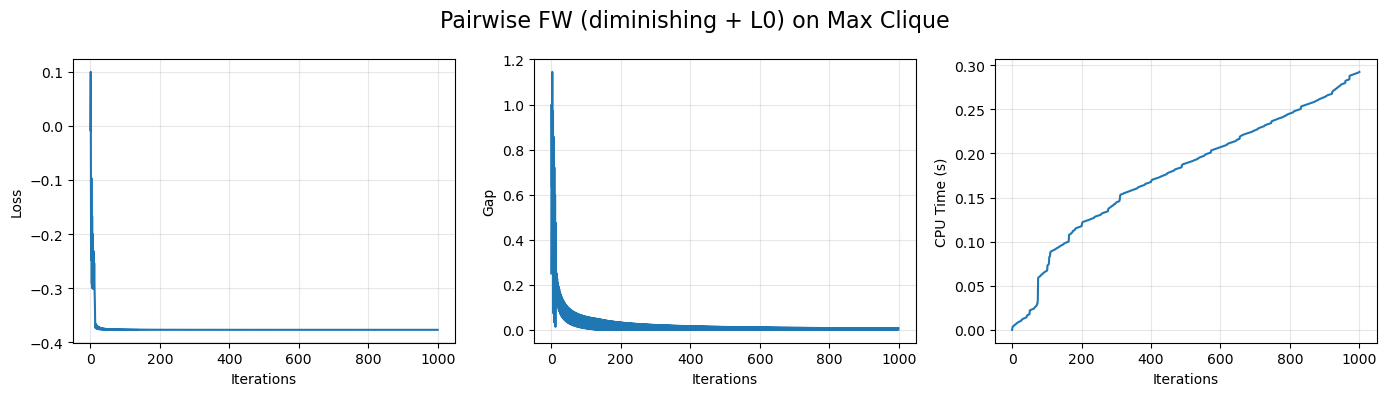

Estimated clique size for Pairwise FW (diminishing + L0) on Max Clique: 3.000


In [43]:
G = nx.Graph()
G.add_edges_from([(0, 1), (1, 2), (2, 0)]) # triangle
G.add_node(3) # isolated node

adj_matrix = nx.to_numpy_array(G)

regularizers = [
    ('L2', phi_l2, grad_phi_l2),
    ('L0', lambda x: phi_l0(x, alpha=0.1, beta=10),
            lambda x: grad_phi_l0(x, alpha=0.1, beta=10))
]

for solver_class, solver_name, solver_dict in solver_configs:
    for line_search in line_search_strats:
        for reg_name, phi_func, grad_phi_func in regularizers:
            title = f'{solver_name} ({line_search} + {reg_name}) on Max Clique'
        
            print(f'Solving Max Clique problem with {title}...')
        
            solver = solver_class(max_iter, tol, line_search)
            fitted_solver = solve_max_clique(adj_matrix, solver, phi_func, grad_phi_func)
            solver_dict[title] = fitted_solver
        
            plot_metrics(fitted_solver, title=title)
            
            x_sol = fitted_solver.x_pred
            clique_val = x_sol.T @ adj_matrix @ x_sol
            clique_size_est = 1 / (1 - clique_val)
            print(f"Estimated clique size for {title}: {clique_size_est:.3f}")
            
            #nx.draw(G, with_labels=True, node_color=x_sol, cmap='viridis')
            #plt.title(f"Node weights for {title}")
            #plt.show()

In [69]:
max_iter = 1000
tol = 1e-6
line_search_strats = [
    'armijo', 
    'diminishing',
    # 'exact',          # Not implemented
    # 'exact_bounded'   # Not implemented
]
solver_configs = [
    (FrankWolfe, "FW", {}),
    (AwayStepFrankWolfe, "Away Step FW", {}),
    (PairwiseFrankWolfe, "Pairwise FW", {})
]

solvers = {}

regularizers = [
    ('L2', phi_l2, grad_phi_l2),
    ('L0', lambda x: phi_l0(x, alpha=0.01, beta=5),
            lambda x: grad_phi_l0(x, alpha=0.01, beta=5))
]

In [63]:
c_path = '/Users/Oksana/Downloads/C125-9/C125-9.mtx'
brock_path = '/Users/Oksana/Downloads/brock800-4/brock800-4.mtx'
gen_path = '/Users/Oksana/Downloads/gen400-p0-9-75/gen400-p0-9-75.mtx'

In [59]:
def load_graph(path):
    adj_matrix = mmread(path).astype(float).todense()
    adj_matrix = np.array(adj_matrix)
    
    assert np.allclose(adj_matrix, adj_matrix.T), 'Matrix is not symmetric'
    print(f'Size: {adj_matrix.shape[0]} nodes')
    
    return adj_matrix

In [57]:
def dimacs_max_clique(adj_matrix):
    for solver_class, solver_name, solver_dict in solver_configs:
        for line_search in line_search_strats:
            for reg_name, phi_func, grad_phi_func in regularizers:
                title = f'{solver_name} ({line_search} + {reg_name}) on Max Clique'
            
                print(f'Solving DIMACS Max Clique problem with {title}...')
            
                solver = solver_class(max_iter, tol, line_search)
                fitted_solver = solve_max_clique(adj_matrix, solver, phi_func, grad_phi_func)
                solver_dict[title] = fitted_solver
            
                plot_metrics(fitted_solver, title=title)
                
                x_sol = fitted_solver.x_pred
                clique_val = x_sol.T @ adj_matrix @ x_sol
                clique_size_est = 1 / (1 - clique_val)
                print(f"Estimated clique size for {title}: {clique_size_est:.3f}")

In [64]:
c_matrix = load_graph(c_path)
brock_matrix = load_graph(brock_path)
gen_matrix = load_graph(gen_path)

Size: 125 nodes
Size: 800 nodes
Size: 400 nodes


Solving DIMACS Max Clique problem with FW (armijo + L2) on Max Clique...


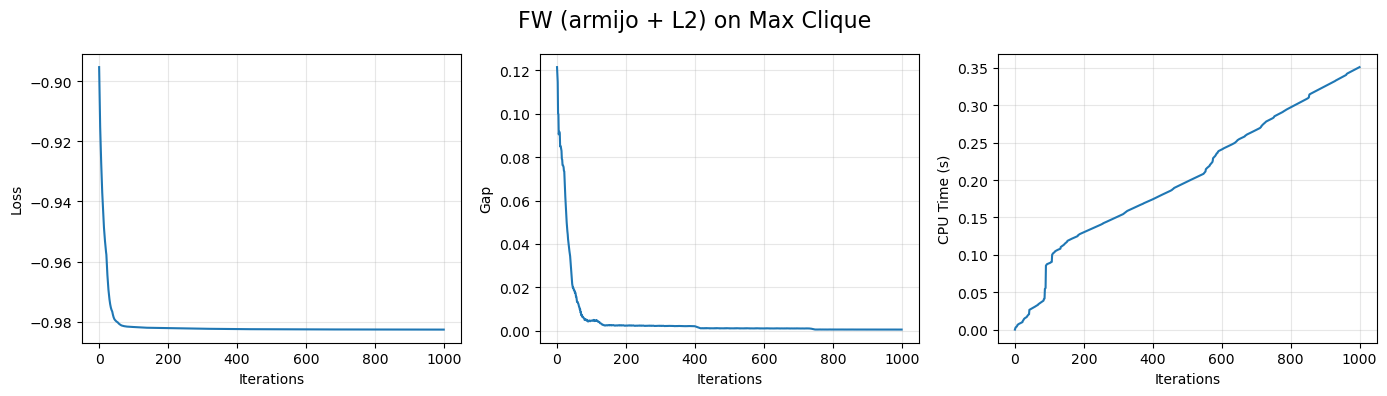

Estimated clique size for FW (armijo + L2) on Max Clique: 28.932
Solving DIMACS Max Clique problem with FW (armijo + L0) on Max Clique...


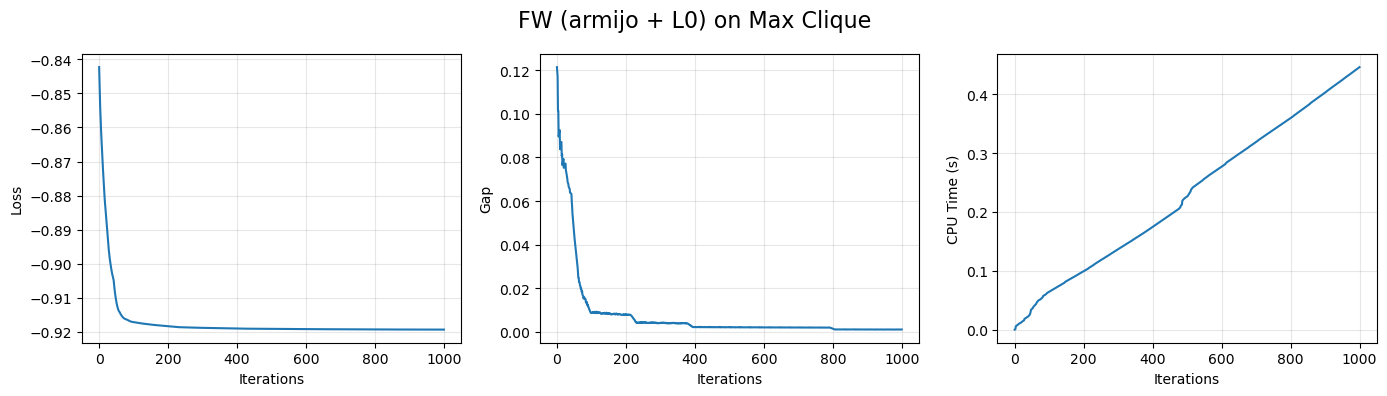

Estimated clique size for FW (armijo + L0) on Max Clique: 28.860
Solving DIMACS Max Clique problem with FW (diminishing + L2) on Max Clique...


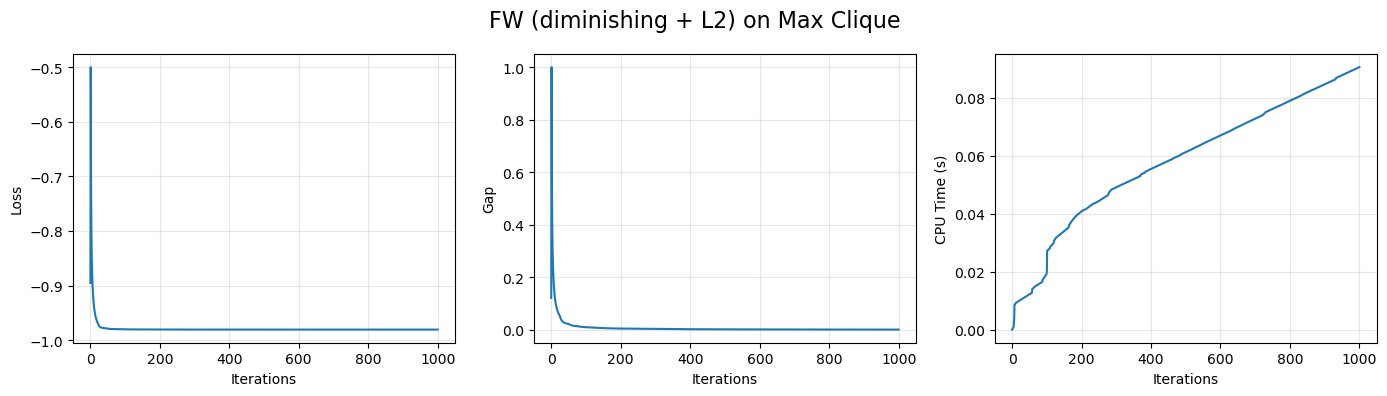

Estimated clique size for FW (diminishing + L2) on Max Clique: 25.994
Solving DIMACS Max Clique problem with FW (diminishing + L0) on Max Clique...


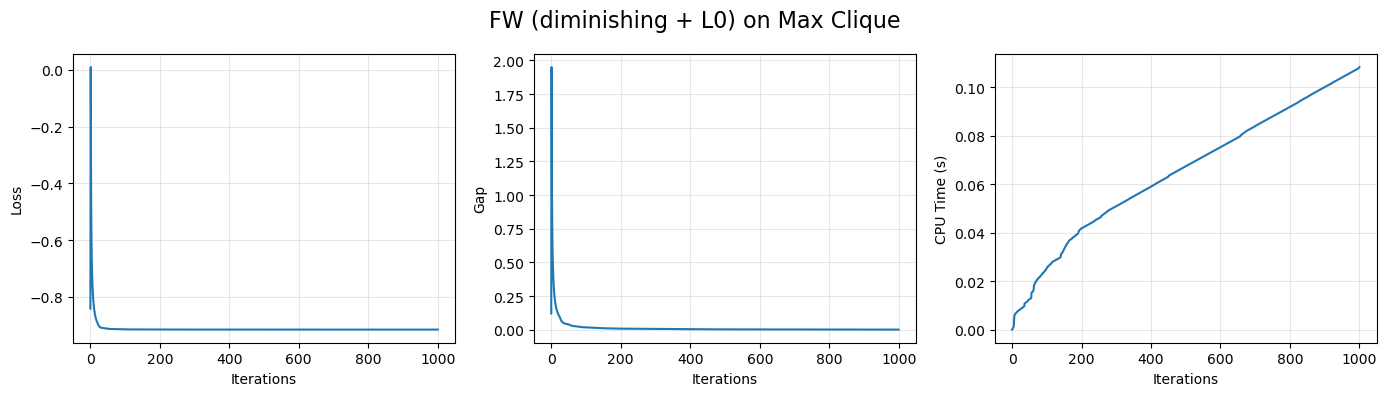

Estimated clique size for FW (diminishing + L0) on Max Clique: 25.994
Solving DIMACS Max Clique problem with Away Step FW (armijo + L2) on Max Clique...


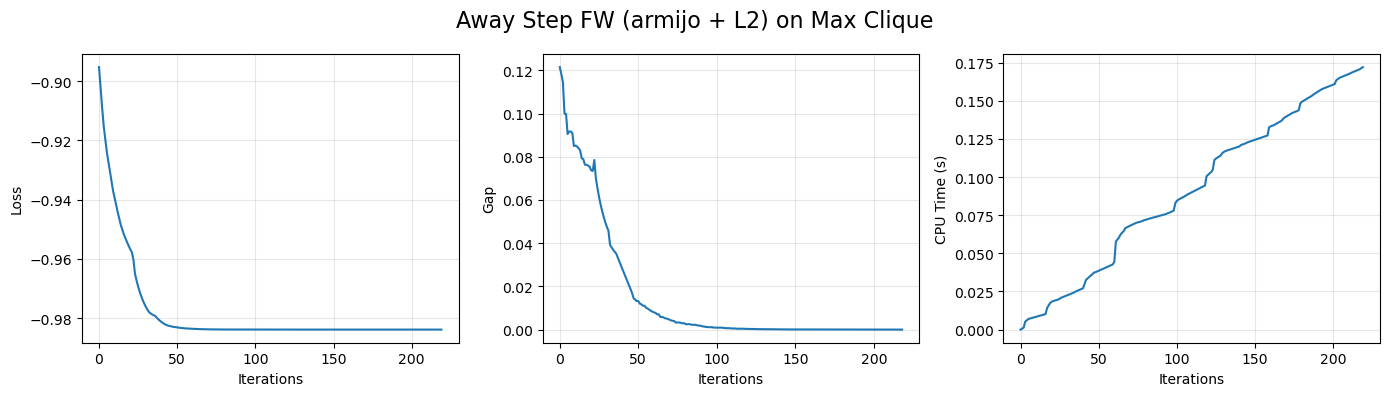

Estimated clique size for Away Step FW (armijo + L2) on Max Clique: 31.000
Solving DIMACS Max Clique problem with Away Step FW (armijo + L0) on Max Clique...


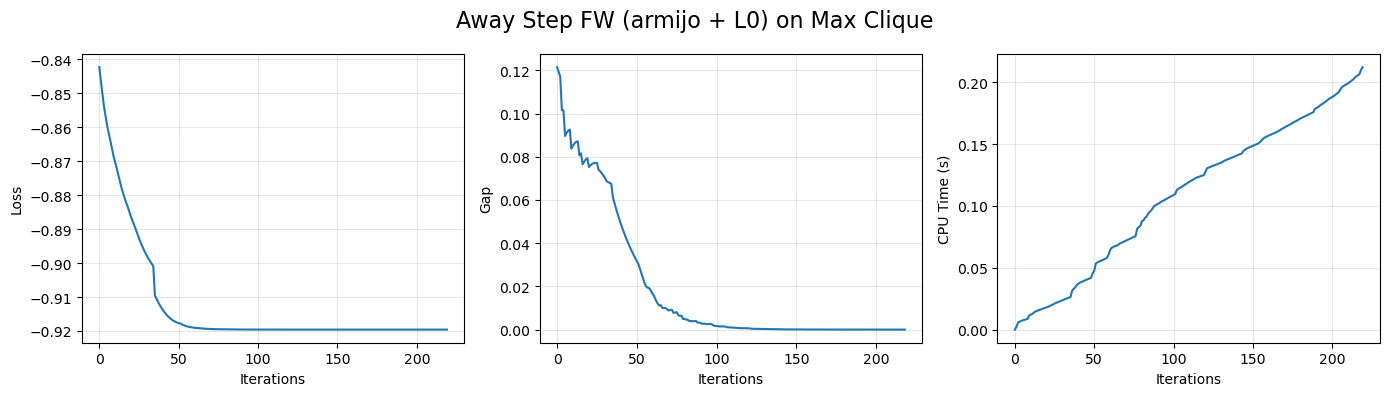

Estimated clique size for Away Step FW (armijo + L0) on Max Clique: 29.000
Solving DIMACS Max Clique problem with Away Step FW (diminishing + L2) on Max Clique...


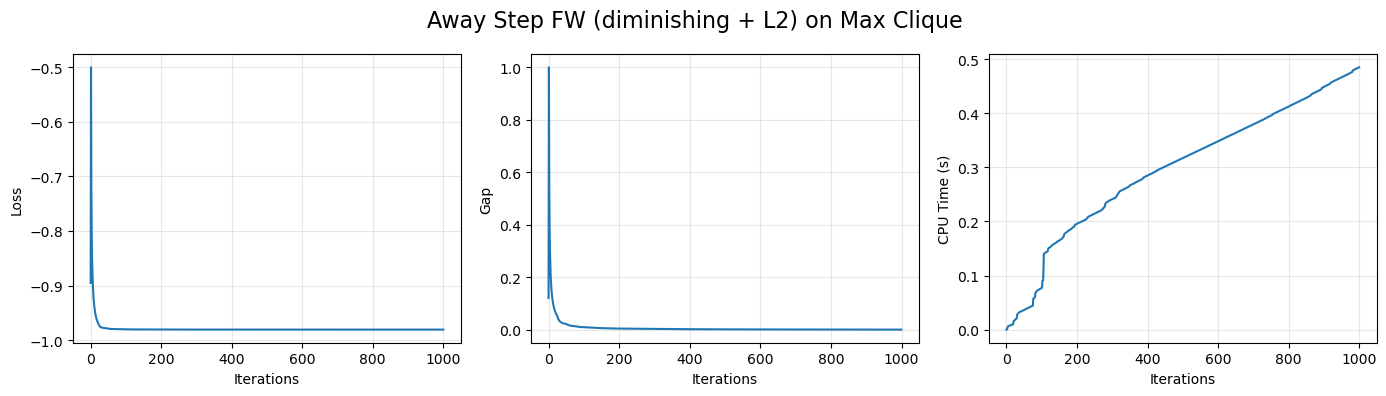

Estimated clique size for Away Step FW (diminishing + L2) on Max Clique: 25.994
Solving DIMACS Max Clique problem with Away Step FW (diminishing + L0) on Max Clique...


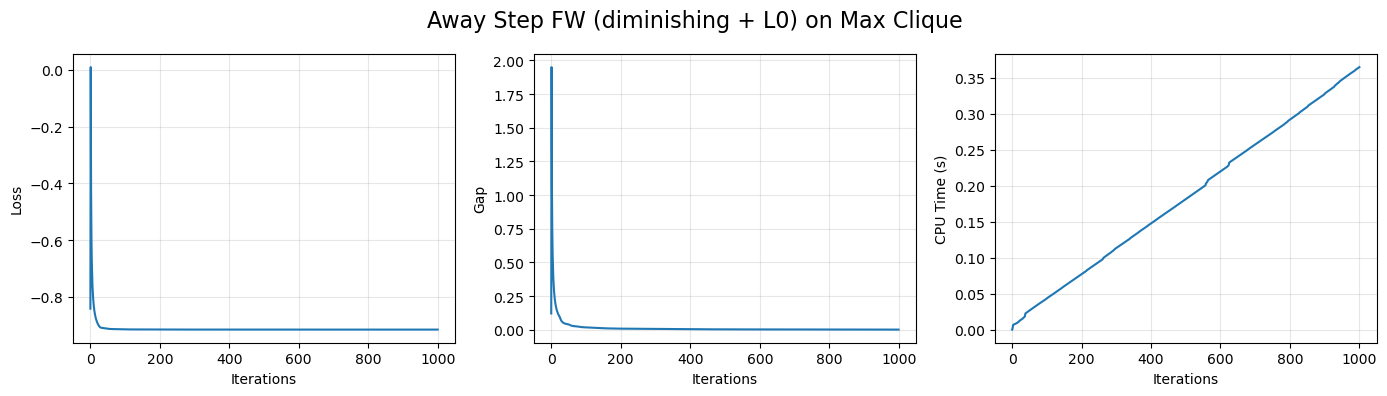

Estimated clique size for Away Step FW (diminishing + L0) on Max Clique: 25.994
Solving DIMACS Max Clique problem with Pairwise FW (armijo + L2) on Max Clique...


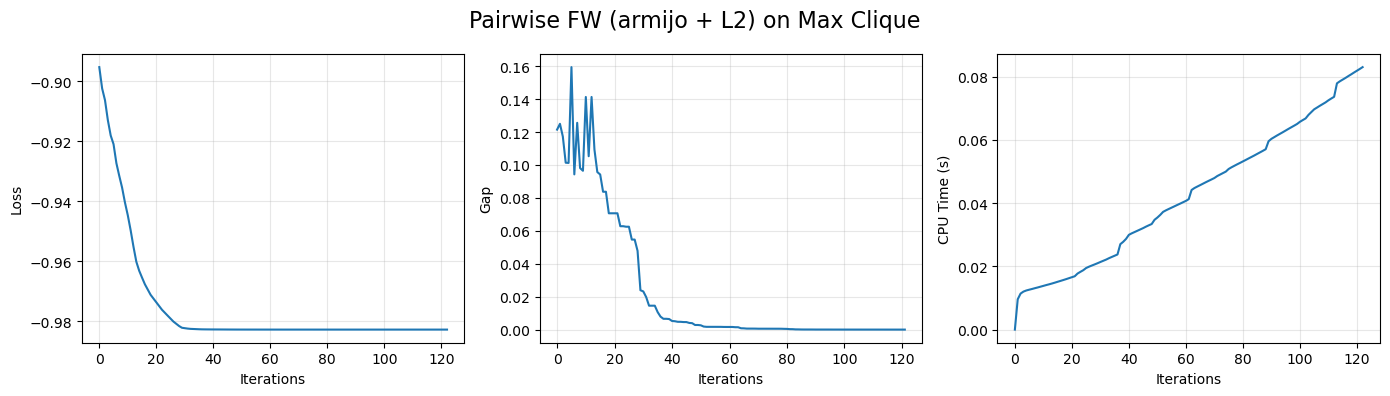

Estimated clique size for Pairwise FW (armijo + L2) on Max Clique: 29.000
Solving DIMACS Max Clique problem with Pairwise FW (armijo + L0) on Max Clique...


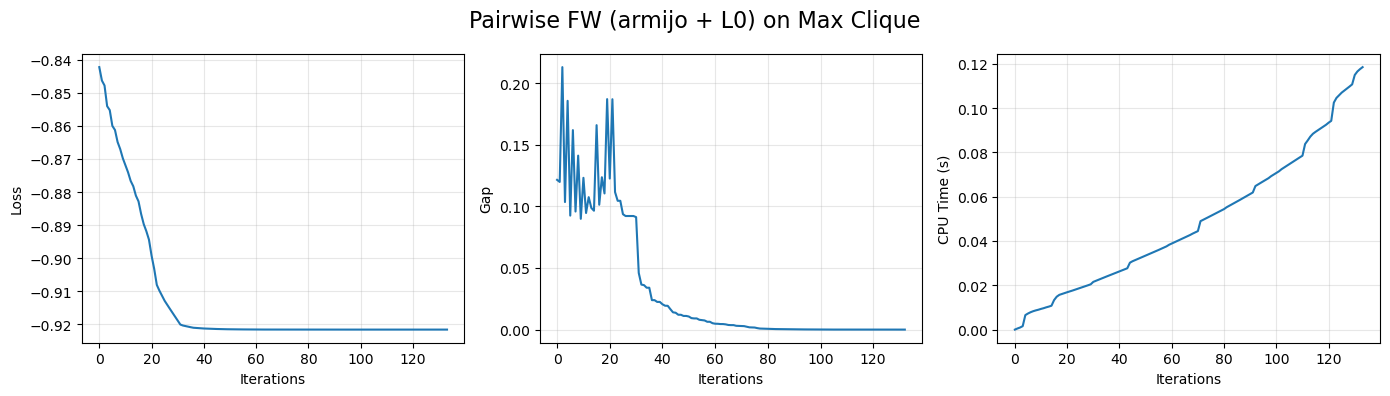

Estimated clique size for Pairwise FW (armijo + L0) on Max Clique: 31.000
Solving DIMACS Max Clique problem with Pairwise FW (diminishing + L2) on Max Clique...


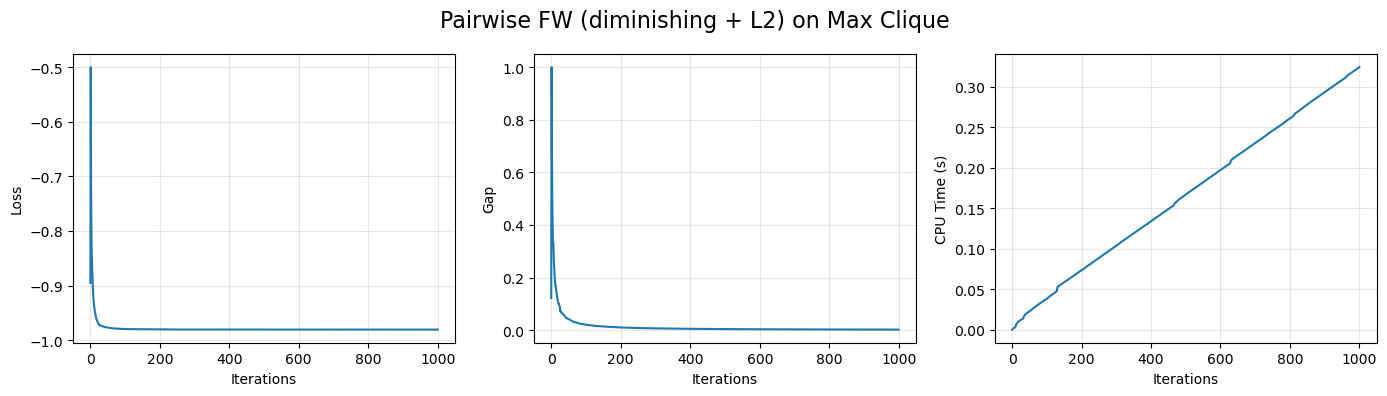

Estimated clique size for Pairwise FW (diminishing + L2) on Max Clique: 25.983
Solving DIMACS Max Clique problem with Pairwise FW (diminishing + L0) on Max Clique...


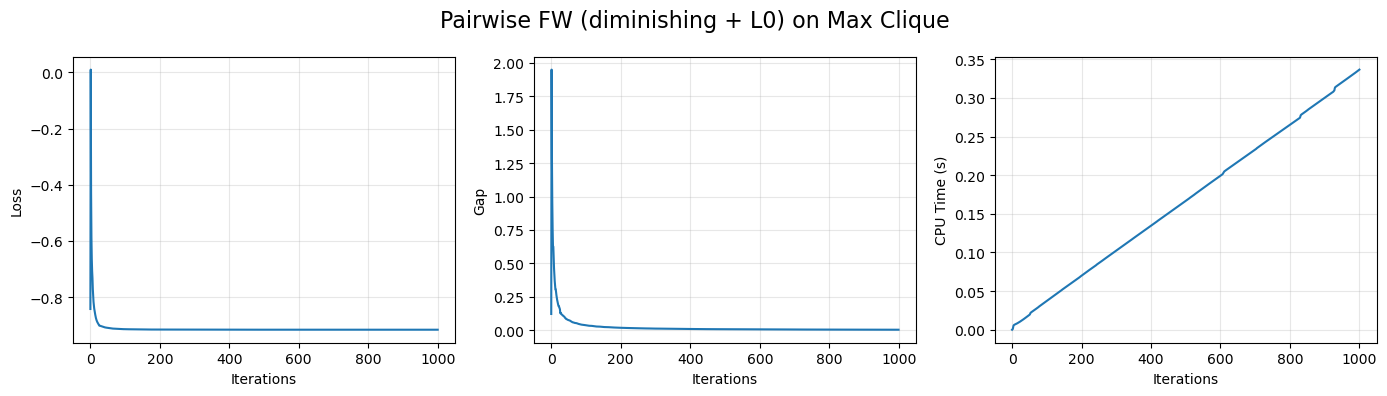

Estimated clique size for Pairwise FW (diminishing + L0) on Max Clique: 25.983


In [70]:
dimacs_max_clique(c_matrix)

Solving DIMACS Max Clique problem with FW (armijo + L2) on Max Clique...


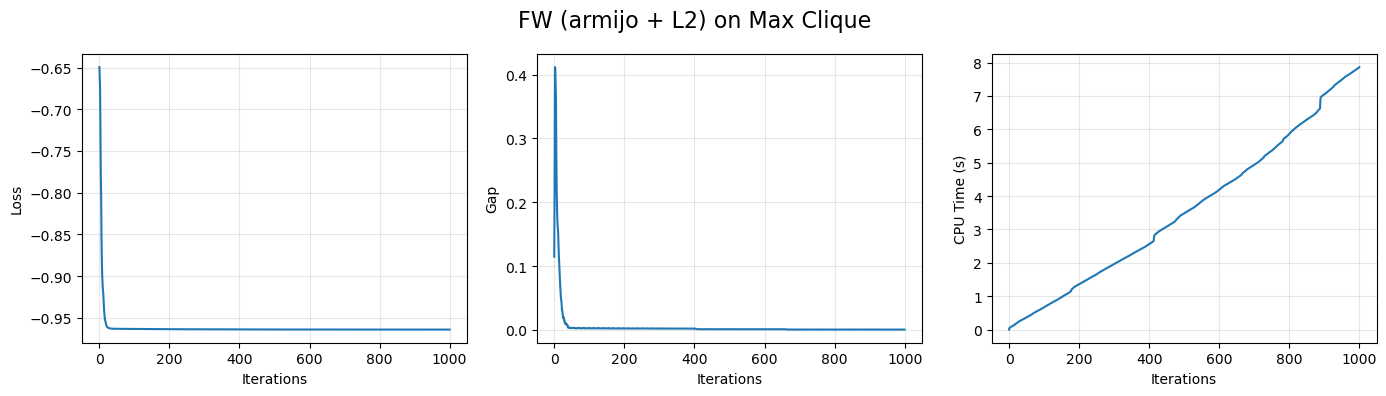

Estimated clique size for FW (armijo + L2) on Max Clique: 13.980
Solving DIMACS Max Clique problem with FW (armijo + L0) on Max Clique...


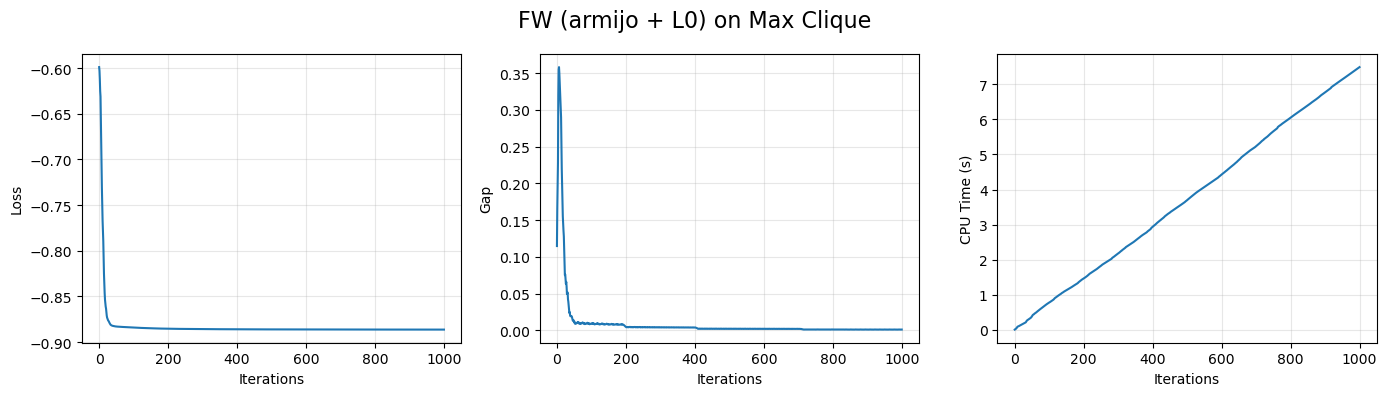

Estimated clique size for FW (armijo + L0) on Max Clique: 13.960
Solving DIMACS Max Clique problem with FW (diminishing + L2) on Max Clique...


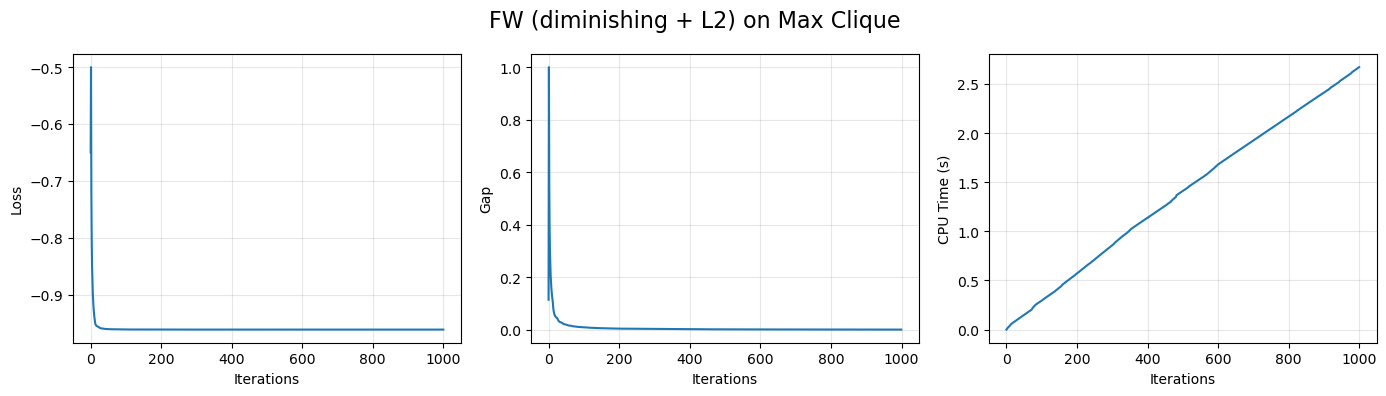

Estimated clique size for FW (diminishing + L2) on Max Clique: 12.999
Solving DIMACS Max Clique problem with FW (diminishing + L0) on Max Clique...


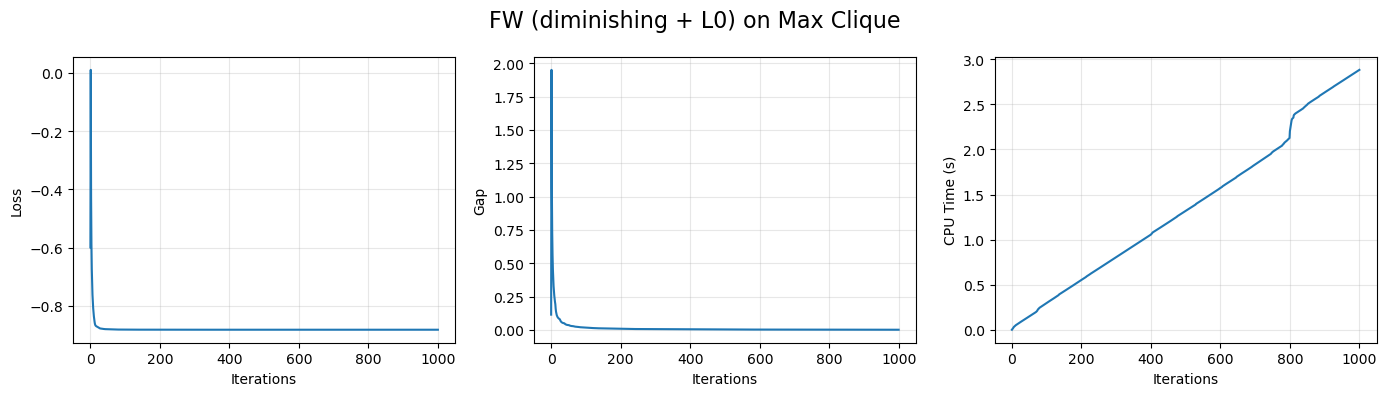

Estimated clique size for FW (diminishing + L0) on Max Clique: 12.999
Solving DIMACS Max Clique problem with Away Step FW (armijo + L2) on Max Clique...


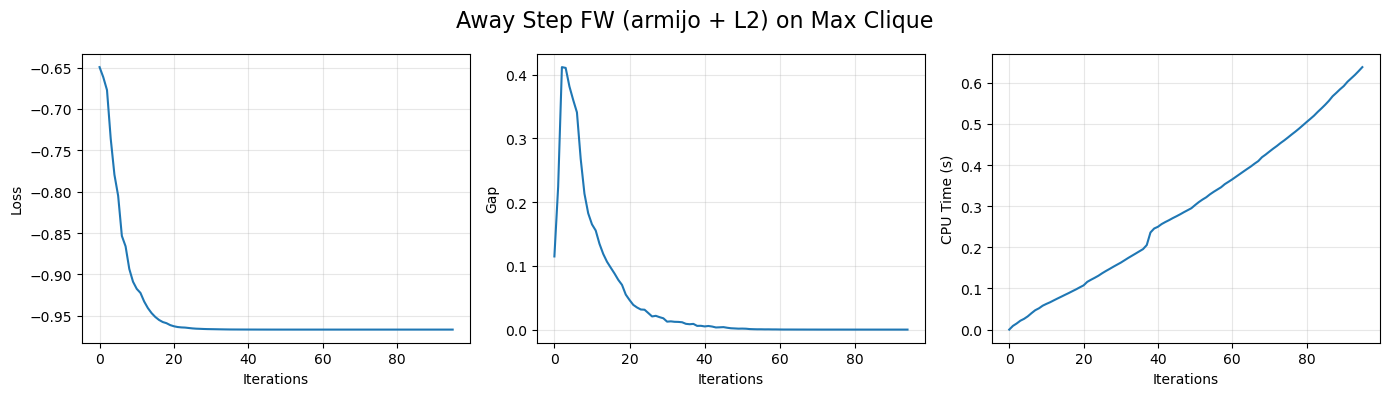

Estimated clique size for Away Step FW (armijo + L2) on Max Clique: 15.000
Solving DIMACS Max Clique problem with Away Step FW (armijo + L0) on Max Clique...


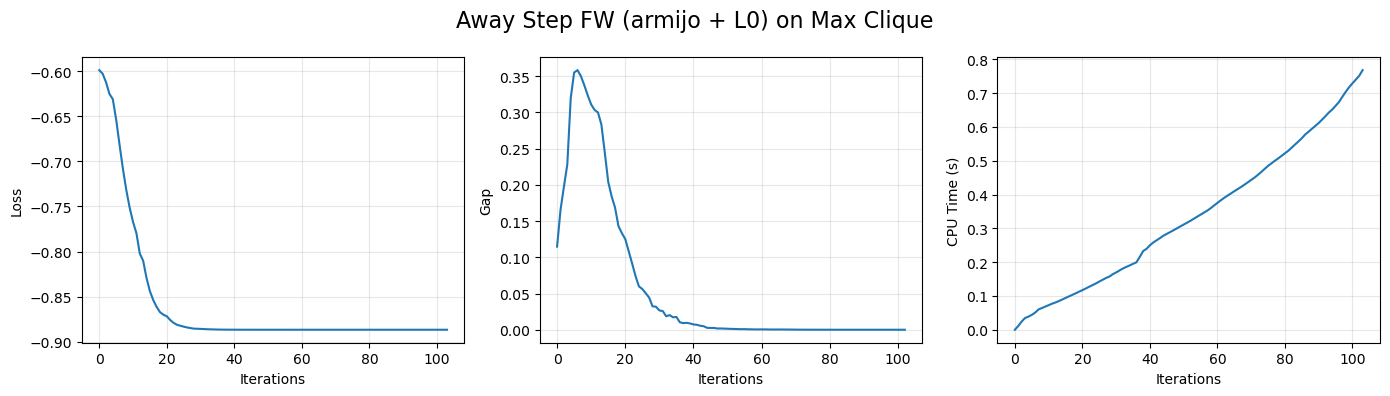

Estimated clique size for Away Step FW (armijo + L0) on Max Clique: 14.000
Solving DIMACS Max Clique problem with Away Step FW (diminishing + L2) on Max Clique...


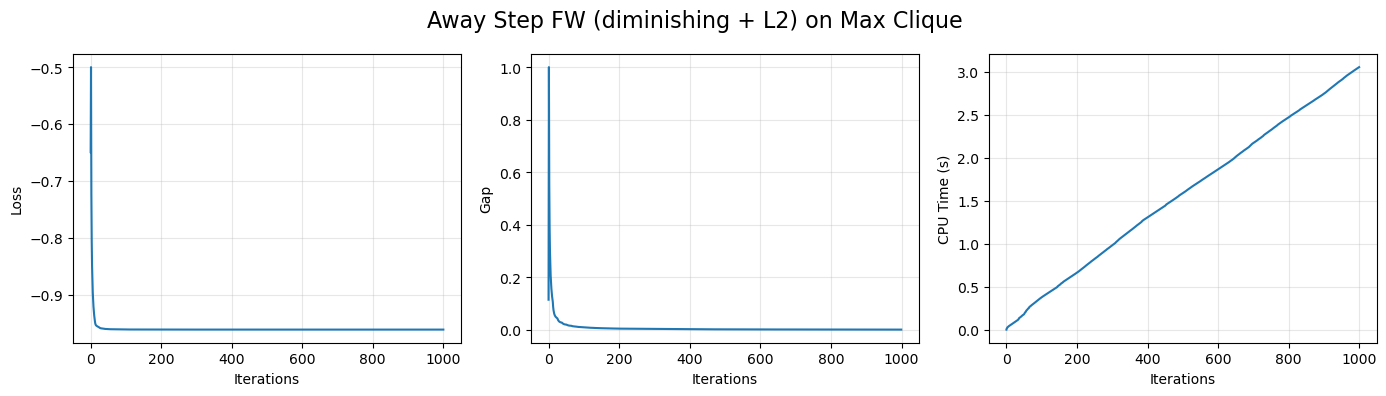

Estimated clique size for Away Step FW (diminishing + L2) on Max Clique: 12.999
Solving DIMACS Max Clique problem with Away Step FW (diminishing + L0) on Max Clique...


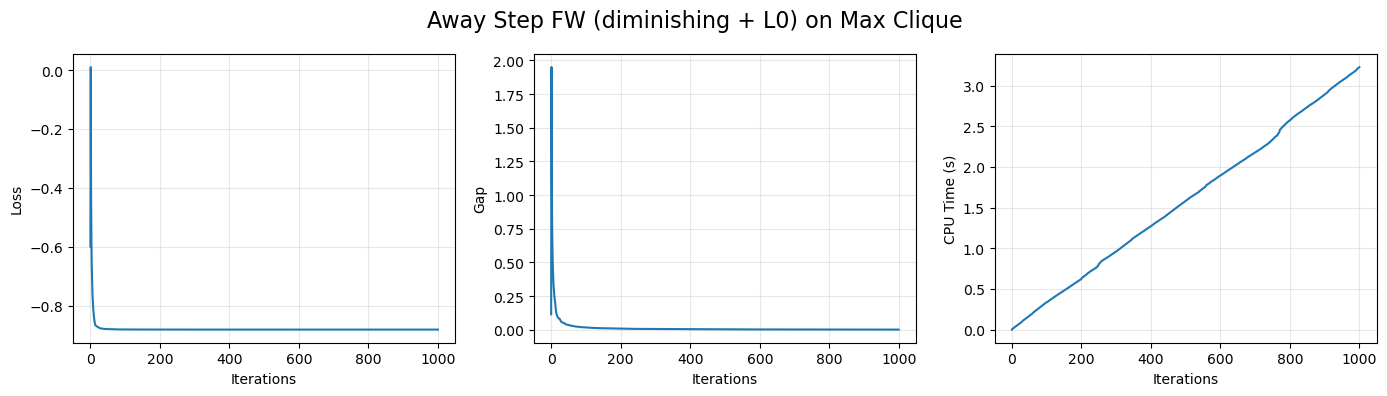

Estimated clique size for Away Step FW (diminishing + L0) on Max Clique: 12.999
Solving DIMACS Max Clique problem with Pairwise FW (armijo + L2) on Max Clique...


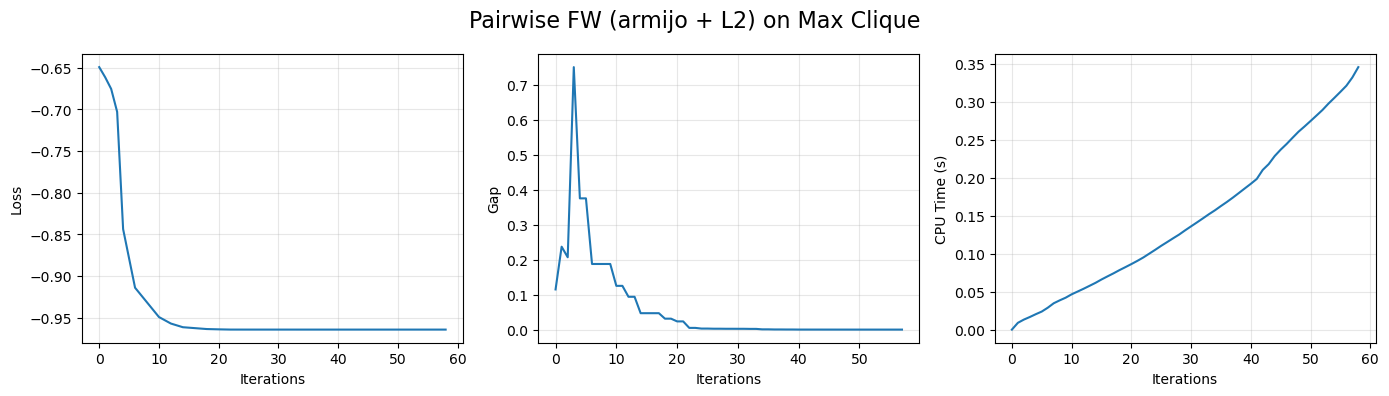

Estimated clique size for Pairwise FW (armijo + L2) on Max Clique: 14.000
Solving DIMACS Max Clique problem with Pairwise FW (armijo + L0) on Max Clique...


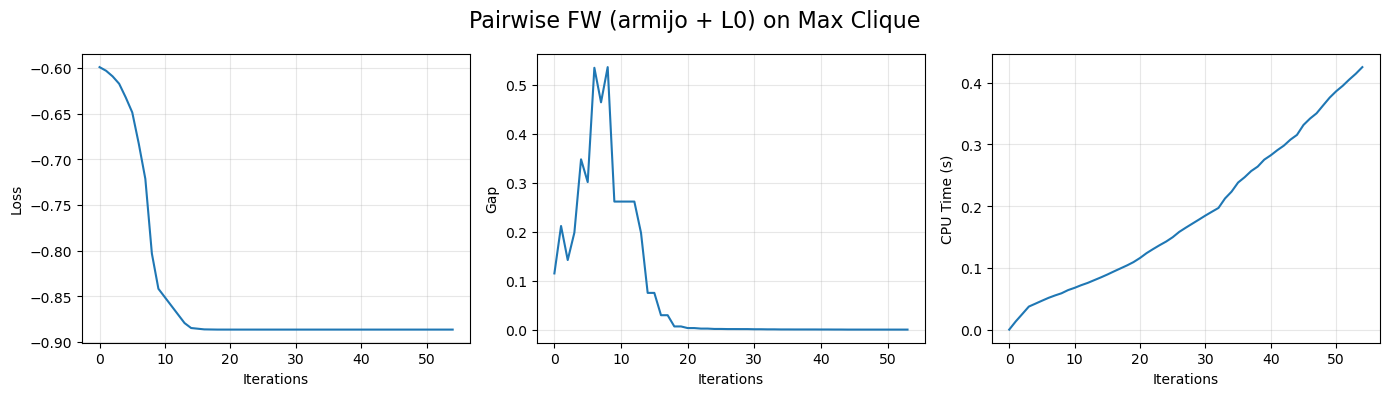

Estimated clique size for Pairwise FW (armijo + L0) on Max Clique: 14.000
Solving DIMACS Max Clique problem with Pairwise FW (diminishing + L2) on Max Clique...


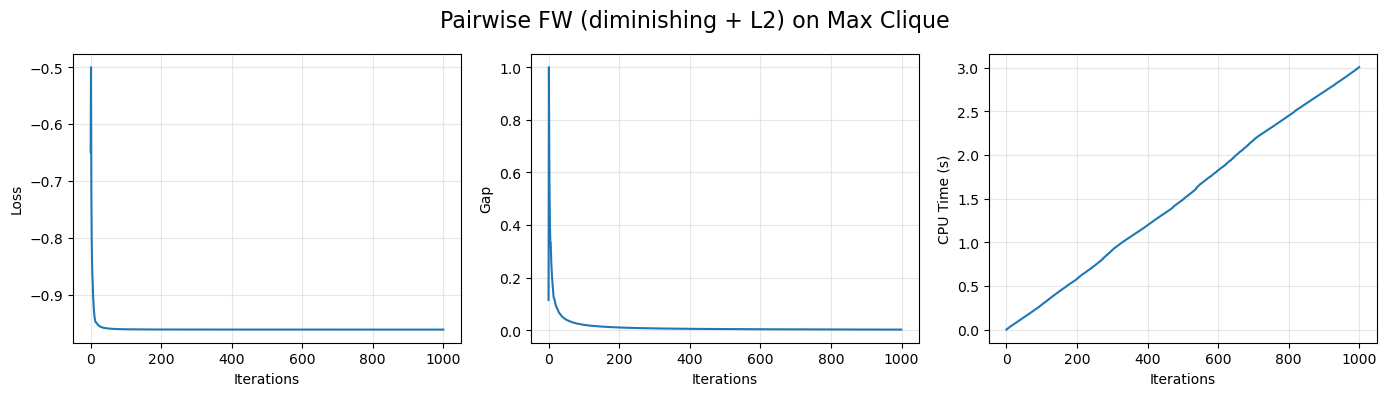

Estimated clique size for Pairwise FW (diminishing + L2) on Max Clique: 12.998
Solving DIMACS Max Clique problem with Pairwise FW (diminishing + L0) on Max Clique...


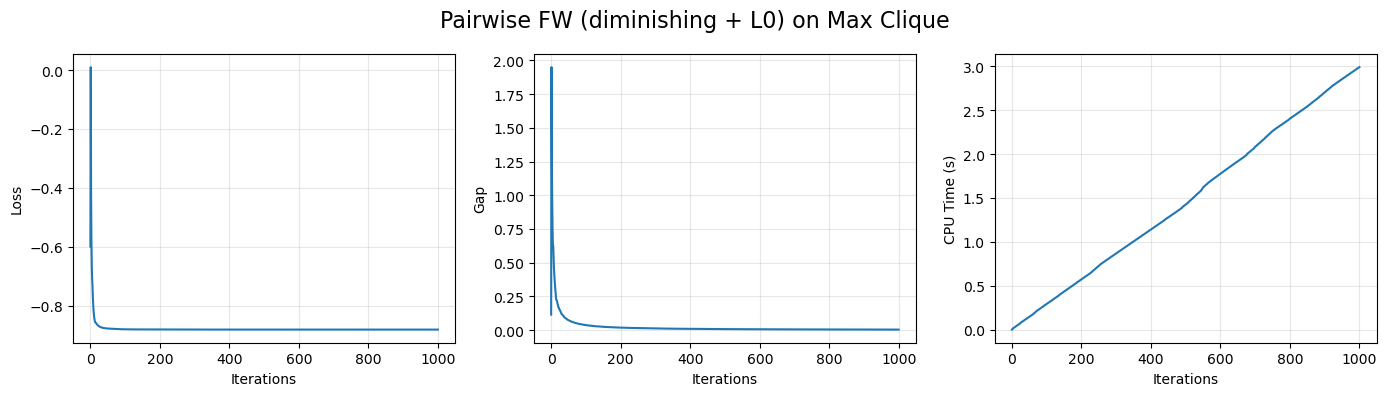

Estimated clique size for Pairwise FW (diminishing + L0) on Max Clique: 12.998


In [71]:
dimacs_max_clique(brock_matrix)

Solving DIMACS Max Clique problem with FW (armijo + L2) on Max Clique...


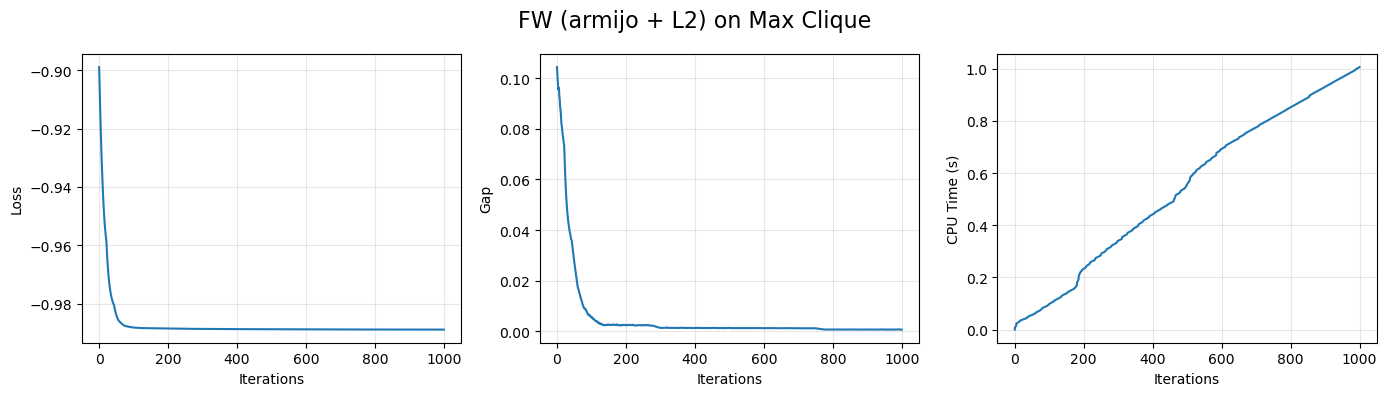

Estimated clique size for FW (armijo + L2) on Max Clique: 44.818
Solving DIMACS Max Clique problem with FW (armijo + L0) on Max Clique...


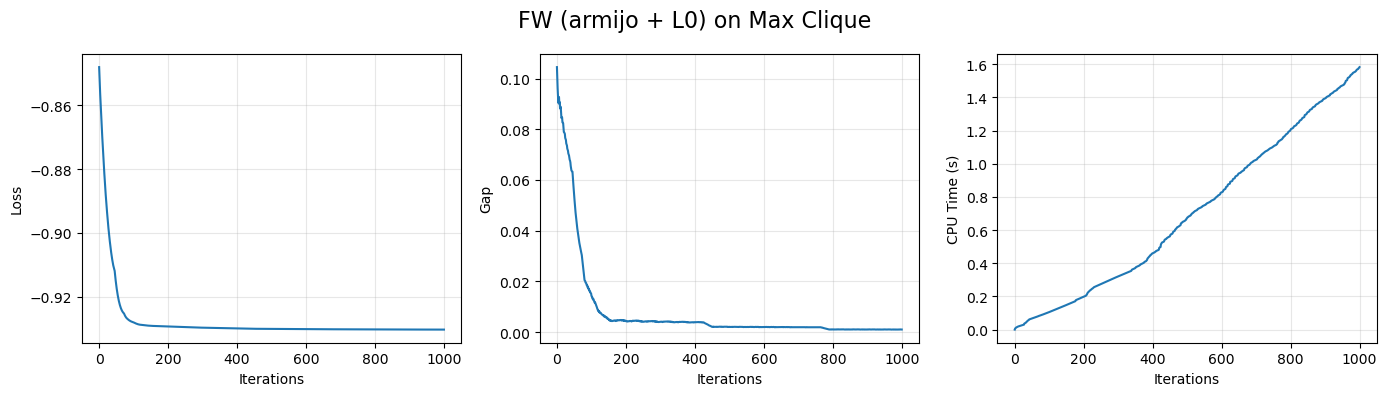

Estimated clique size for FW (armijo + L0) on Max Clique: 44.636
Solving DIMACS Max Clique problem with FW (diminishing + L2) on Max Clique...


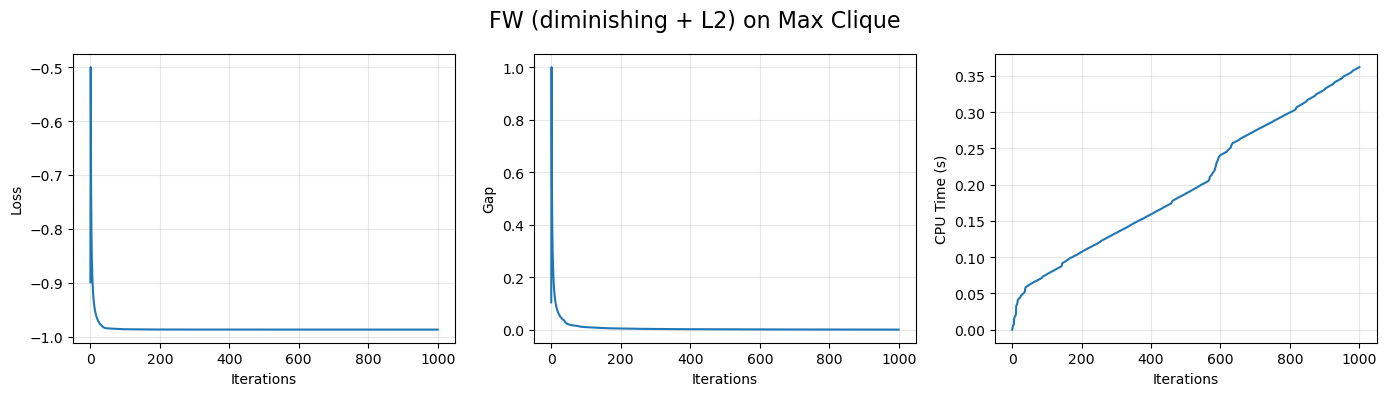

Estimated clique size for FW (diminishing + L2) on Max Clique: 37.982
Solving DIMACS Max Clique problem with FW (diminishing + L0) on Max Clique...


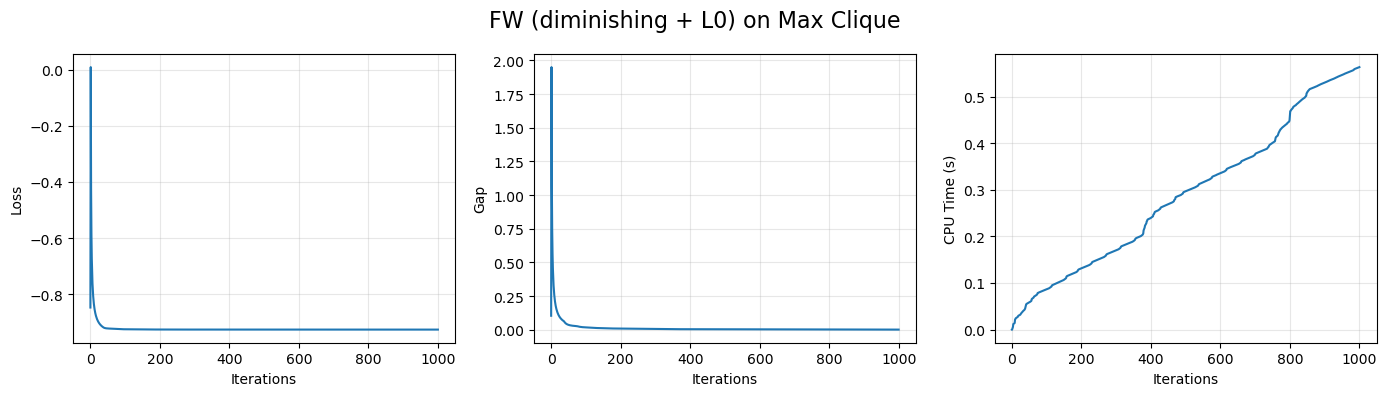

Estimated clique size for FW (diminishing + L0) on Max Clique: 37.982
Solving DIMACS Max Clique problem with Away Step FW (armijo + L2) on Max Clique...


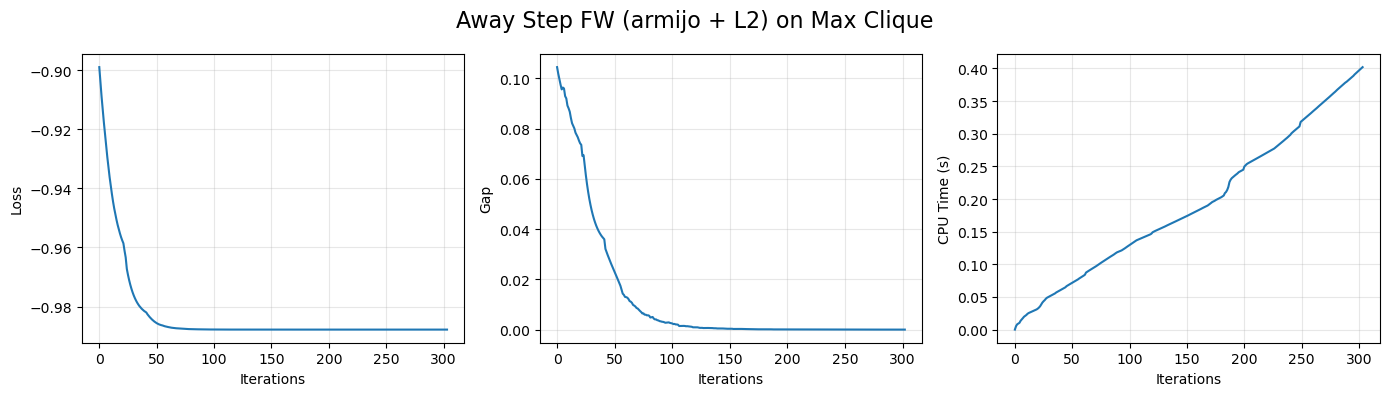

Estimated clique size for Away Step FW (armijo + L2) on Max Clique: 41.000
Solving DIMACS Max Clique problem with Away Step FW (armijo + L0) on Max Clique...


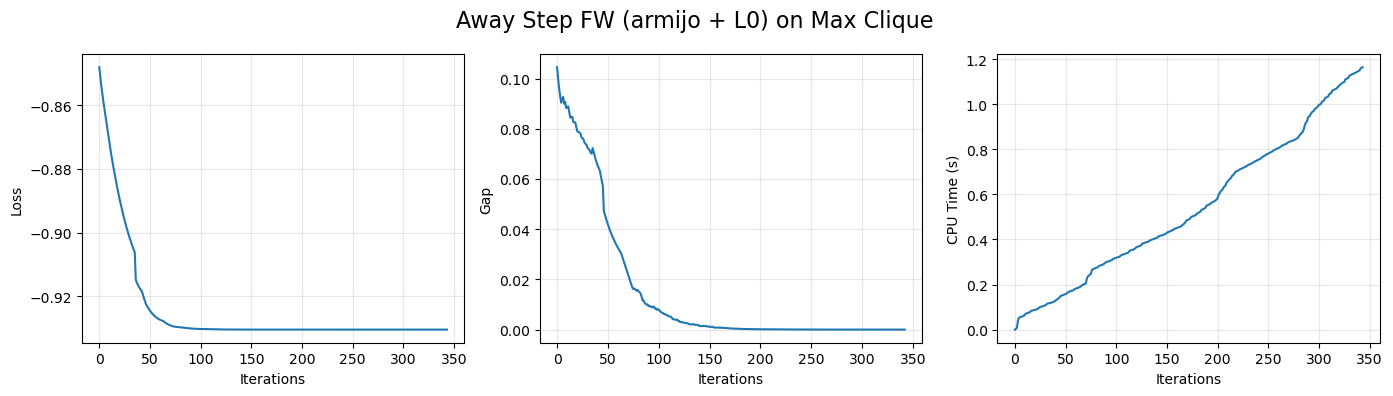

Estimated clique size for Away Step FW (armijo + L0) on Max Clique: 45.000
Solving DIMACS Max Clique problem with Away Step FW (diminishing + L2) on Max Clique...


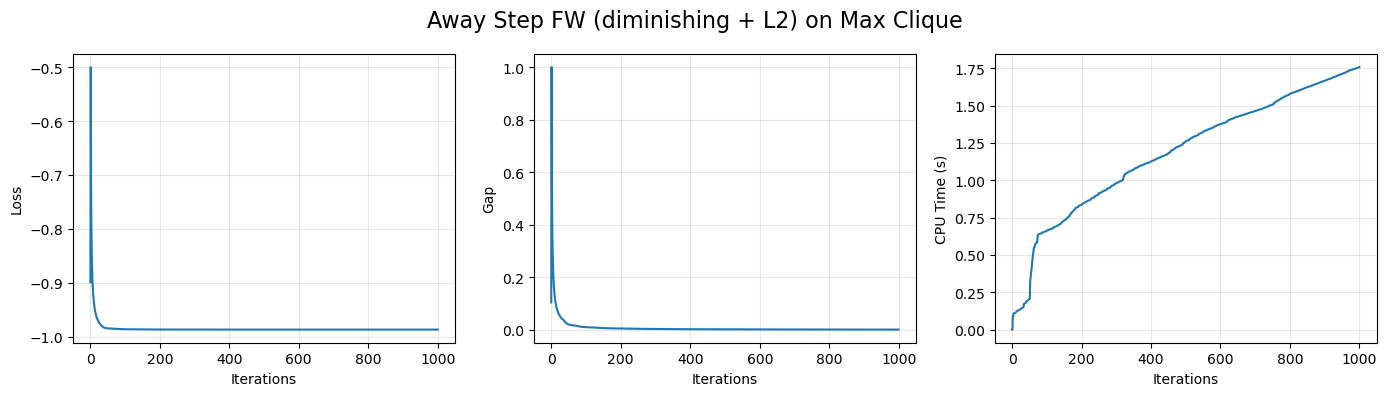

Estimated clique size for Away Step FW (diminishing + L2) on Max Clique: 37.982
Solving DIMACS Max Clique problem with Away Step FW (diminishing + L0) on Max Clique...


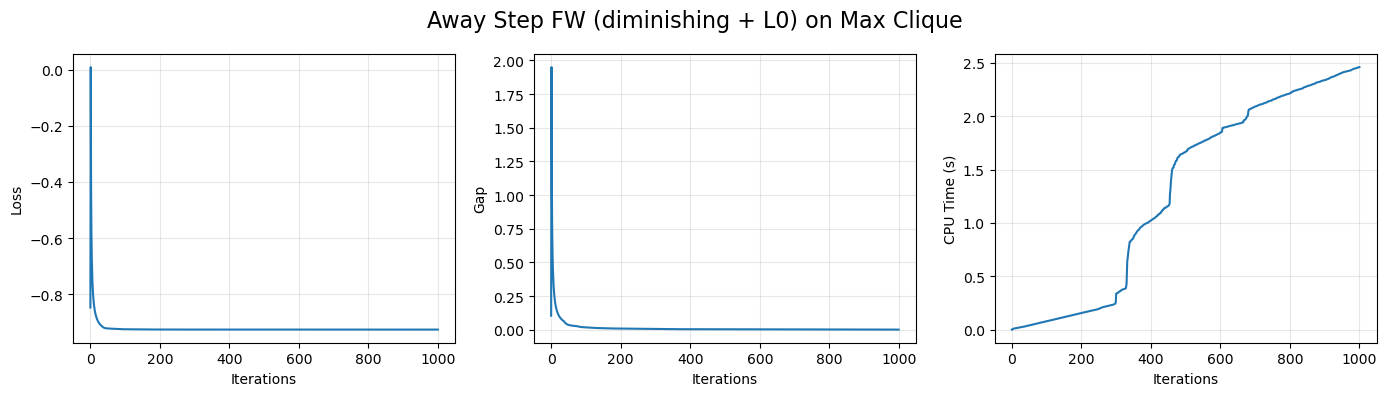

Estimated clique size for Away Step FW (diminishing + L0) on Max Clique: 37.982
Solving DIMACS Max Clique problem with Pairwise FW (armijo + L2) on Max Clique...


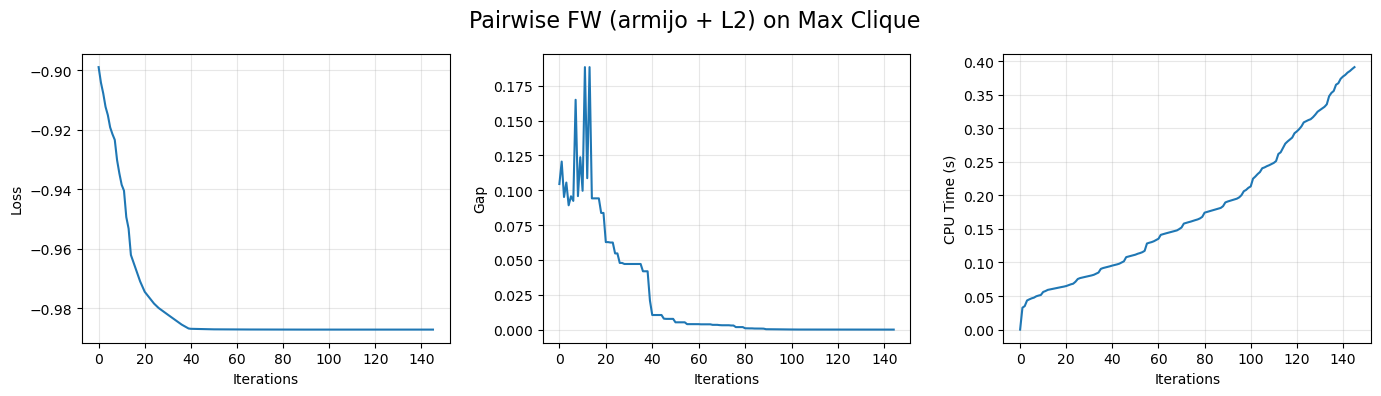

Estimated clique size for Pairwise FW (armijo + L2) on Max Clique: 39.000
Solving DIMACS Max Clique problem with Pairwise FW (armijo + L0) on Max Clique...


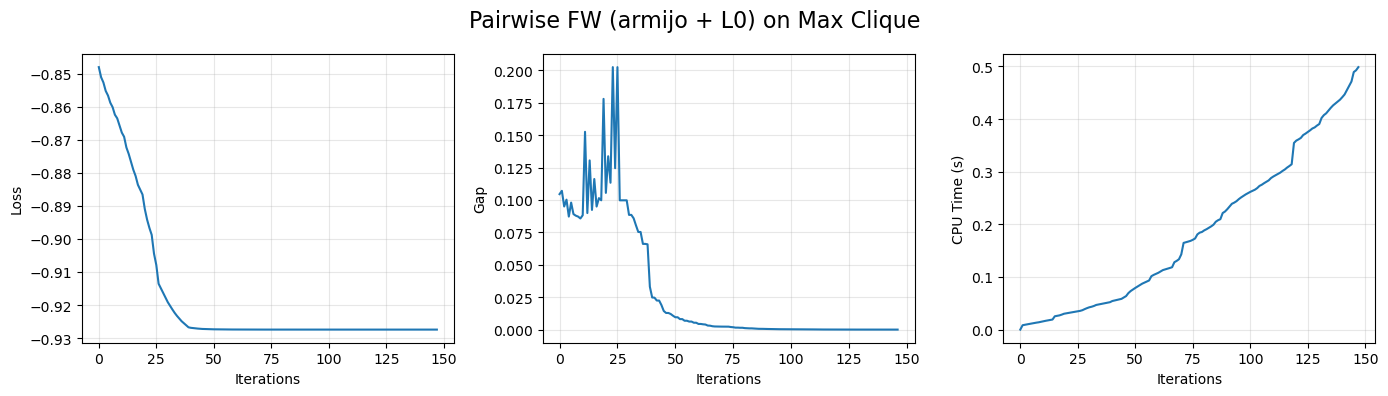

Estimated clique size for Pairwise FW (armijo + L0) on Max Clique: 39.000
Solving DIMACS Max Clique problem with Pairwise FW (diminishing + L2) on Max Clique...


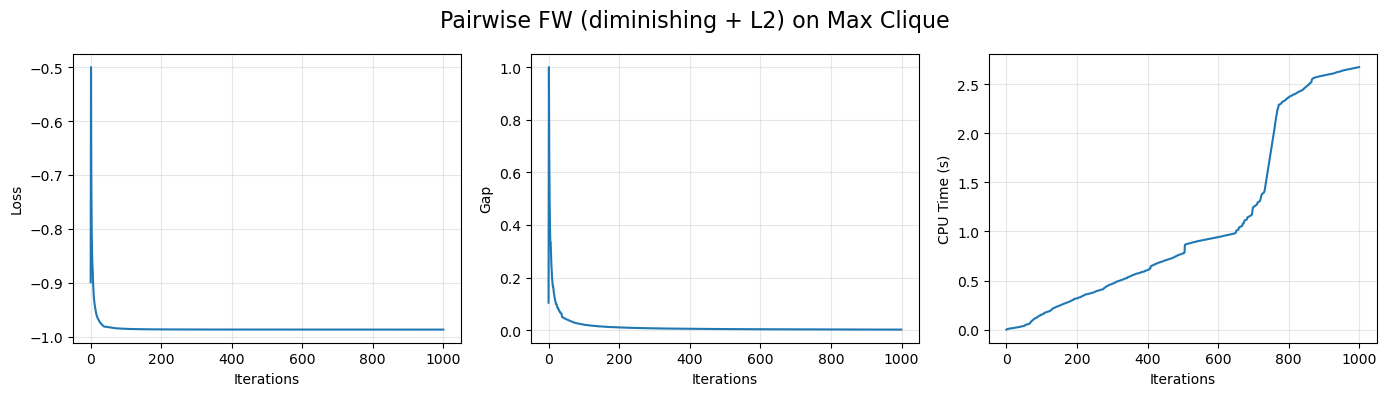

Estimated clique size for Pairwise FW (diminishing + L2) on Max Clique: 37.949
Solving DIMACS Max Clique problem with Pairwise FW (diminishing + L0) on Max Clique...


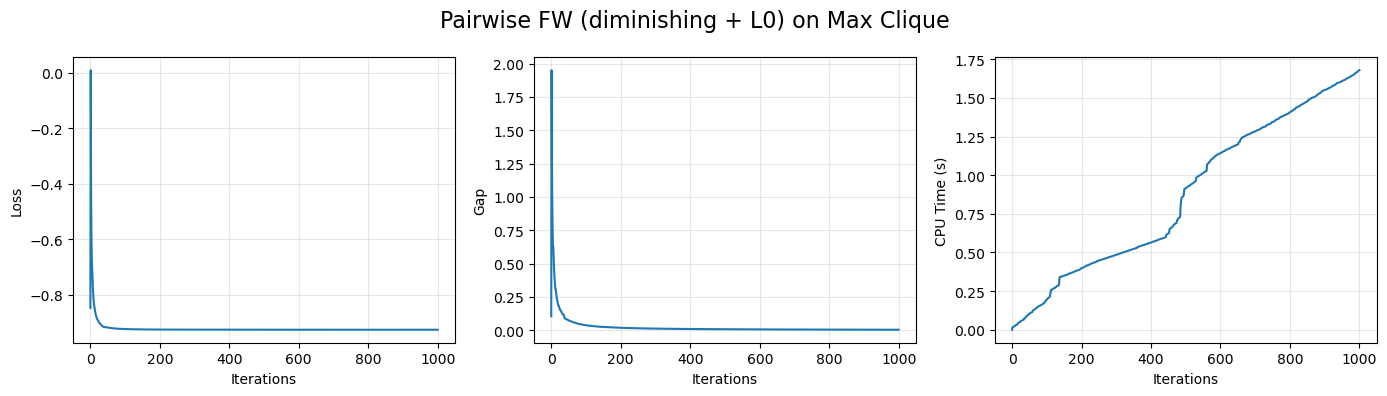

Estimated clique size for Pairwise FW (diminishing + L0) on Max Clique: 37.949


In [72]:
dimacs_max_clique(gen_matrix)